# 06: Link Prediction — Full Pipeline (Final)

**מטרה:** בניית מודל ML מלא לחיזוי שיתופי פעולה עתידיים בין שחקנים, לפי עיצוב Train/Test/Evaluation: **X_train**=גרף 1990-2010, **Y_train**=קשרים חדשים 2011-2015; **X_test**=גרף 1990-2015, **Y_test**=קשרים חדשים 2016-2020; **Evaluation**=בחירת המודל הטוב ביותר, אימונו מחדש על Train+Test יחד, והרצתו על הגרף המלא ההיסטורי עד 2020, נבדק מול תוצאות 2021-2025 האמיתיות, **עם `years_ahead` כפיצ'ר אמיתי במודל** כדי לבדוק אמפירית איזה אופק חיזוי (1-5 שנים) הכי מדויק.

## מבנה הנוטבוק — 4 חלקים ברורים:

| חלק | מה נבנה | קובץ/Cutoff |
|---|---|---|
| **חלק 1 — TRAIN** | גרף בסיס עד 2010, כל הפיצ'רים, ובניית **Train Set** (יעדים: קשרים חדשים 1-5 שנים אחרי 2010 → 2011-2015) | `G_1990_2010` → `train_df` |
| **חלק 2 — TEST** | גרף בסיס עד 2015 ("הגרף המלא עד 2015" — מכיל את כל מה שהיה ידוע ב-Train + התקופה שביניהם), ובניית **Test Set** (יעדים: קשרים חדשים 1-5 שנים אחרי 2015 → 2016-2020) | `G_1990_2015` → `test_df` |
| **חלק 3 — EVALUATION** | אימון Random Forest על Train, הערכה על Test (Precision/Recall/F1/AUC), Feature Importance, Feature Selection, וניתוח שגיאות (FP/FN/TP + לפי אופק חיזוי) — בחירת המודל הטוב ביותר | `rf_all`, `rf_sel` |
| **חלק 4 — EVALUATION על הגרף המלא** | **אימון מחדש על Train+Test יחד** (`rf_final`/`scaler_final`, אותם היפר-פרמטרים ואותם פיצ'רים נבחרים שנבחרו בחלק 3) והרצתו על פיצ'רים מהגרף ההיסטורי המלא עד 2020 (`G_full_2020`, 1918-2020), ובדיקה מול קשרים אמיתיים שנוצרו בפועל ב-2021-2025 (holdout שלישי, לא ספקולטיבי) | `G_full_2020` → `future_predictions_2021_2025_validated.csv` |

## עיצוב זמני (Temporal Design) — X/Y לפי בקשת המשתמש + years_ahead:

| | **X (Graph features)** | **Y (Target labels)** |
|---|---|---|
| **Train** | `G_1990_2010` (1990-2010) | קשרים חדשים שנוצרו בתוך 1-5 שנים אחרי 2010 (2011-2015), עם `years_ahead` כפיצ'ר |
| **Test** | `G_1990_2015` (1990-2015, "הגרף המלא עד 2015") | קשרים חדשים שנוצרו בתוך 1-5 שנים אחרי 2015 (2016-2020), עם `years_ahead` כפיצ'ר |

- פיצ'רים ($X$) מחושבים **רק** מהגרף הקיים בנקודת החיתוך (ללא מידע מהעתיד — מניעת Data Leakage)
- **`years_ahead` (1,2,3,4,5) הוא פיצ'ר אמיתי** — כל זוג מופיע עם כמה שורות (אחת לכל אופק שבו הוא positive/negative), כדי שהמודל ילמד את התלות בזמן ונוכל לבדוק איזה אופק הכי מדויק
- קשרים שכבר קיימים בבסיס מוסרים לחלוטין — מנבאים **רק קשרים חדשים**
- **בדיקת Data Leakage:** שנת החיתוך עצמה (2010 ל-Train, 2015 ל-Test) **נכללת** בגרף הפיצ'רים (X) אך **אף פעם לא** נחשבת "קשר חדש" ב-Y — כי היא כבר קיימת ב-`G_base`. נבדוק זאת במפורש בסוף חלק 1 וחלק 2 (assertion על השנה המדויקת של כל קשר חדש).
- **אישור מתודולוגי:** החלוקה הזו (Train על 1990-2010→2011-2015, Test על 1990-2015→2016-2020, ולבסוף אימון מחדש על Train+Test יחד והרצה על הגרף המלא ההיסטורי מול 2021-2025) הוצגה למרצה הקורס ואושרה כנכונה מתודולוגית, בכפוף לאי-דליפת מידע מהעתיד בבניית הפיצ'רים והדגימה השלילית — נבדק ומתועד בהמשך.

**תוצאה:** מודל Random Forest שמוערך על Test (2016-2020) עם Precision, Recall, F1, AUC-ROC, ובחירת אופק החיזוי האופטימלי, ולבסוף **מאומן מחדש על Train+Test יחד ומורץ על הגרף המלא עד 2020** ונבדק מול תוצאות 2021-2025 האמיתיות.


In [1]:
import sys
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# ML imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif

# Local imports
sys.path.append('../src')
from graph_build import load_cast_edges, build_full_graph, _actor_id
from link_prediction import (
    build_graph_for_years,
    get_new_pairs, sample_negatives,
    build_link_dataset, compute_centralities,
    train_random_forest, evaluate_model
)
from link_features import build_feature_matrix, svd_node_embeddings, walk_based_node_embeddings

# Plot settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✅ All imports successful")

✅ All imports successful


# 🟦 חלק 1 — TRAIN

בונים את גרף הבסיס עד 2010, את כל הפיצ'רים, ואת ה-**Train Set** (יעדים: קשרים חדשים 1-5 שנים אחרי 2010 → 2011-2015).

## שלב 1: טעינת נתונים וגרפים

In [2]:
# Load data
cast_df = load_cast_edges('../data/processed/cast_edges.csv')
movies_df = pd.read_csv('../data/processed/movies.csv') if Path('../data/processed/movies.csv').exists() \
    else cast_df[['movie_slug','movie_title','year','genre','directors']].drop_duplicates('movie_slug')

# IMPORTANT (data quality): ~14% of cast rows have no Wikipedia slug for the actor
# (actor_slug is NaN) — graph_build.build_full_graph() falls back to a normalized-name
# node ID ('__name__:...') for those actors when building the graph. Our own feature-
# building code groups cast_df rows by actor identity too (temporal / genre / director
# stats), so it MUST use the exact same identity — otherwise ~25% of graph nodes (the
# fallback-ID actors) silently get zeroed-out features. Add that identity as a column
# here, once, and use 'actor_id' (not raw 'actor_slug') for all such grouping below.
cast_df['actor_id'] = [
    _actor_id(slug, name) for slug, name in zip(cast_df['actor_slug'], cast_df['actor_name'])
]
print(f"📊 Actors with no wiki slug (fallback name-based ID): "
      f"{cast_df['actor_slug'].isna().sum()} / {len(cast_df)} rows "
      f"({cast_df[cast_df['actor_slug'].isna()]['actor_id'].nunique()} unique actors)")

# Temporal design (per user's request):
# - Train:  X features from G_1990_2010 (graph up to 2010). Y_train = new pairs that connect
#           in G_1990_2015 (i.e. new links formed 2011-2015) but were NOT connected in G_1990_2010.
# - Test:   X features from G_1990_2015 ("graph up to 2015"). Y_test = new pairs that connect
#           in G_1990_2020 (i.e. new links formed 2016-2020) but were NOT connected in G_1990_2015.
# G_full_2025 is a SEPARATE, TRUE full graph (from the earliest films, 1918, through 2025) used
# ONLY for the final Evaluation step: retrain the best model and run it on the ENTIRE graph
# (all links known through 2025) to make speculative future (2026+) predictions.
G_1990_2010 = build_graph_for_years(cast_df, year_min=1990, year_max=2010)
G_1990_2015 = build_graph_for_years(cast_df, year_min=1990, year_max=2015)
G_1990_2020 = build_graph_for_years(cast_df, year_min=1990, year_max=2020)
G_full_2025 = build_graph_for_years(cast_df, year_min=1918, year_max=2025)

print(f"📊 G_1990_2010 (train features): {G_1990_2010.number_of_nodes()} nodes, {G_1990_2010.number_of_edges()} edges")
print(f"📊 G_1990_2015 (test features):  {G_1990_2015.number_of_nodes()} nodes, {G_1990_2015.number_of_edges()} edges")
print(f"📊 G_1990_2020 (test target, new links through 2020): {G_1990_2020.number_of_nodes()} nodes, {G_1990_2020.number_of_edges()} edges")
print(f"📊 G_full_2025 (1918-2025, full history): {G_full_2025.number_of_nodes()} nodes, {G_full_2025.number_of_edges()} edges")
print(f"📊 cast_df columns: {cast_df.columns.tolist()}")

📊 Actors with no wiki slug (fallback name-based ID): 420 / 2972 rows (360 unique actors)
📊 G_1990_2010 (train features): 443 nodes, 1053 edges
📊 G_1990_2015 (test features):  691 nodes, 1907 edges
📊 G_1990_2020 (test target, new links through 2020): 837 nodes, 2653 edges
📊 G_full_2025 (1918-2025, full history): 1365 nodes, 5947 edges
📊 cast_df columns: ['movie_slug', 'movie_title', 'year', 'genre', 'directors', 'cast_source', 'billing_position', 'actor_name', 'actor_slug', 'period', 'actor_id']


## שלב 2: בניית כל הפיצ'רים (43 פיצ'רים) — כולל years_ahead

### פיצ'רים:
- **Topological (5):** Common Neighbors, Jaccard, Adamic-Adar, Preferential Attachment, Shortest Path
- **Centrality (16):** Degree, Betweenness, Closeness, Eigenvector (u/v/product/diff לכל אחד)
- **Temporal (10):** career_length, career_overlap, film_count, is_alive ועוד (מניעת Data Leakage)
- **Genre/Director (7):** genre_diversity, genre_overlap, director_count, director_overlap ועוד
- **Matrix Factorization (2):** `svd_cosine_sim`, `svd_dot_product` — TruncatedSVD על מטריצת השכנות המשוקללת (פירוק ישיר של הגרף)
- **Embedding Methods (2):** `walk_cosine_sim`, `walk_dot_product` — embedding מבוסס random-walk (סגנון node2vec/DeepWalk): הליכות אקראיות על הגרף → מטריצת קו-אוקורנס → TruncatedSVD (שיטת NetMF, מוכחת שקולה ל-DeepWalk/node2vec). ניסינו להתקין את חבילת `node2vec` (תלויה ב-`gensim`) אך זו לא תומכת ב-Python 3.14 בסביבה הזו (דורשת Visual C++ Build Tools להידור מקור) — לכן מומשה גרסה עצמאית (ללא תלויות נוספות) שמשיגה את אותה מטרה: embedding מבנייתי מבוסס-הליכה, שונה מהותית מ-Matrix Factorization הפשוט (שמשתמש רק בשכנות ישירה, hop אחד)
- **years_ahead (1):** אופק החיזוי בשנים (1,2,3,4,5) — פיצ'ר אמיתי, לא רק פרמטר קונספטואלי. מאפשר למודל ללמוד את התלות בזמן ולבדוק אמפירית איזה אופק הכי מדויק


## שלב 3: יצירת Train/Test Sets רב-אופקיים (Multi-Horizon) עם years_ahead כפיצ'ר

לכל בסיס (train=2010, test=2015) בונים דוגמאות עבור **5 אופקי חיזוי שונים** (1,2,3,4,5 שנים), עם `years_ahead` כעמודת פיצ'ר. זוג שחקנים שהתחבר תוך 3 שנים ייחשב positive באופקים 3/4/5 (קומולטיבי), ו-NEGATIVE-משותף (זוגות שלעולם לא מתחברים תוך 5 שנים) משמש בכל האופקים.

In [24]:
def build_multi_horizon_dataset(G_base, cast_df_local, cutoff_year, horizons, seed=42, neg_ratio=1.5):
    """
    Build a link-prediction dataset spanning MULTIPLE prediction horizons, with
    `years_ahead` as an explicit feature column (not just a fixed parameter).

    For each horizon h in `horizons`:
      - positive pairs = pairs NOT connected in G_base but connected any time within
        (cutoff_year, cutoff_year+h] (cumulative — "will they collaborate within h years?")
      - a SHARED pool of true negatives (pairs that never connect within max(horizons)
        years) is reused across every horizon, so the same negative example appears
        once per horizon with a different years_ahead value.

    All other features (topological, centrality, temporal, genre/director, SVD) are
    computed ONCE per unique pair from G_base — they don't depend on the horizon,
    only the label and years_ahead value do.
    """
    print(f"  Base graph (cutoff={cutoff_year}): {G_base.number_of_nodes()} nodes, {G_base.number_of_edges()} edges")

    # ---- 1. Positive pairs per horizon (cumulative) ----
    pos_by_horizon = {}
    for h in horizons:
        G_future_h = build_graph_for_years(cast_df_local, year_min=1990, year_max=cutoff_year + h)
        pos_by_horizon[h] = get_new_pairs(G_base, G_future_h)
        print(f"    +{h}y ({cutoff_year}->{cutoff_year + h}): {len(pos_by_horizon[h])} positive pairs")

    all_positive_pairs = set()
    for h in horizons:
        all_positive_pairs |= set(pos_by_horizon[h])

    # ---- 2. Shared pool of TRUE negatives (never connect within any tested horizon) ----
    # NOTE on neg_ratio semantics: the negative pool is shared and gets REPLICATED once per
    # horizon in the final row-expanded dataset (step 4 below), but positives are NOT replicated
    # uniformly (each pair only appears in the horizons where it's actually positive, and earlier
    # horizons have far fewer positives than later ones). So sizing the pool off the max-horizon
    # positive count would badly overweight negatives at the row level (e.g. neg_ratio=1 could
    # give a final ~1:2 pos:neg row ratio instead of 1:1). Basing it on the AVERAGE per-horizon
    # positive count instead means: pool_size * len(horizons) \u2248 neg_ratio * total_positive_rows,
    # so neg_ratio actually reflects the final row-level pos:neg ratio, as expected.
    avg_pos_per_horizon = sum(len(p) for p in pos_by_horizon.values()) / len(horizons)
    n_neg = int(avg_pos_per_horizon * neg_ratio)
    neg_pairs = sample_negatives(G_base, n_samples=n_neg, exclude_pairs=all_positive_pairs, seed=seed)
    neg_pairs_set = set(neg_pairs)
    print(f"    Shared negative pool: {len(neg_pairs)} pairs (reused across all {len(horizons)} horizons)")

    # ---- 3. Compute base features ONCE for every unique pair (positives ∪ negatives) ----
    all_pairs = list(all_positive_pairs) + list(neg_pairs)
    centralities = compute_centralities(G_base)
    svd_emb = svd_node_embeddings(G_base, n_components=32, seed=seed)
    walk_emb = walk_based_node_embeddings(G_base, n_components=32, seed=seed)

    X_base, feat_names_base = build_feature_matrix(G_base, all_pairs, centralities)
    base_feat_df = pd.DataFrame(X_base, columns=feat_names_base)
    base_feat_df.insert(0, 'v', [p[1] for p in all_pairs])
    base_feat_df.insert(0, 'u', [p[0] for p in all_pairs])

    def cosine_sim(a, b):
        na, nb = np.linalg.norm(a), np.linalg.norm(b)
        return float(np.dot(a, b) / (na * nb)) if na > 0 and nb > 0 else 0.0

    zero_vec = np.zeros(32)
    svd_cos, svd_dot, walk_cos, walk_dot = [], [], [], []
    for u, v in all_pairs:
        eu, ev = svd_emb.get(u, zero_vec), svd_emb.get(v, zero_vec)
        svd_cos.append(cosine_sim(eu, ev))
        svd_dot.append(float(np.dot(eu, ev)))
        wu, wv = walk_emb.get(u, zero_vec), walk_emb.get(v, zero_vec)
        walk_cos.append(cosine_sim(wu, wv))
        walk_dot.append(float(np.dot(wu, wv)))
    base_feat_df['svd_cosine_sim'] = svd_cos
    base_feat_df['svd_dot_product'] = svd_dot
    base_feat_df['walk_cosine_sim'] = walk_cos
    base_feat_df['walk_dot_product'] = walk_dot

    # ---- Temporal + Genre/Director features (also computed once, based on cutoff_year) ----
    death_file = Path('../data/processed/actor_death_years.csv')
    death_dict = {}
    if death_file.exists():
        d = pd.read_csv(death_file)
        death_dict = dict(zip(d['actor_slug'], d['death_year']))

    past = cast_df_local[cast_df_local['year'] <= cutoff_year]
    actor_stats = (
        past.groupby('actor_id')['year']
        .agg(['min', 'max', 'count'])
        .rename(columns={'min': 'first_year', 'max': 'last_year', 'count': 'film_count'})
    )
    actor_stats['career_length'] = actor_stats['last_year'] - actor_stats['first_year'] + 1
    actor_stats['recent'] = (actor_stats['last_year'] >= (cutoff_year - 5)).astype(int)
    astats = actor_stats.to_dict('index')

    actor_genres, actor_directors = {}, {}
    for actor, grp in past.groupby('actor_id'):
        genres = set()
        for g in grp['genre'].dropna():
            genres.update([x.strip() for x in str(g).split(',') if x.strip()])
        directors = set()
        for dd in grp['directors'].dropna():
            directors.update([x.strip() for x in str(dd).split(',') if x.strip()])
        actor_genres[actor] = list(genres)
        actor_directors[actor] = list(directors)

    temporal_rows, gd_rows = [], []
    for u, v in all_pairs:
        us, vs = astats.get(u, {}), astats.get(v, {})
        u_first, u_last = us.get('first_year', cutoff_year), us.get('last_year', cutoff_year)
        v_first, v_last = vs.get('first_year', cutoff_year), vs.get('last_year', cutoff_year)
        temporal_rows.append({
            'career_overlap':      max(0, min(u_last, v_last) - max(u_first, v_first)),
            'u_career_length':     us.get('career_length', 0),
            'v_career_length':     vs.get('career_length', 0),
            'u_recent':            us.get('recent', 0),
            'v_recent':            vs.get('recent', 0),
            'u_alive':             1 if death_dict.get(u, 9999) > cutoff_year else 0,
            'v_alive':             1 if death_dict.get(v, 9999) > cutoff_year else 0,
            'collaboration_count': G_base.number_of_edges(u, v) if G_base.has_edge(u, v) else 0,
            'u_film_count':        us.get('film_count', 0),
            'v_film_count':        vs.get('film_count', 0),
        })
        ug, vg = actor_genres.get(u, []), actor_genres.get(v, [])
        ud, vd = actor_directors.get(u, []), actor_directors.get(v, [])
        gd_rows.append({
            'genre_overlap':     len(set(ug) & set(vg)),
            'same_main_genre':   1 if ug and vg and ug[0] == vg[0] else 0,
            'u_genre_diversity': len(set(ug)),
            'v_genre_diversity': len(set(vg)),
            'director_overlap':  len(set(ud) & set(vd)),
            'u_director_count':  len(set(ud)),
            'v_director_count':  len(set(vd)),
        })

    base_feat_df = pd.concat([
        base_feat_df.reset_index(drop=True),
        pd.DataFrame(temporal_rows).reset_index(drop=True),
        pd.DataFrame(gd_rows).reset_index(drop=True),
    ], axis=1)

    pair_index = {(row.u, row.v): i for i, row in base_feat_df.iterrows()}

    # ---- 4. Replicate the base feature row across every horizon, with the correct label ----
    # A pair that becomes positive only at a LARGER horizon (e.g. connects in year+3) is
    # simply skipped for smaller horizons (1,2) — it's neither a valid positive nor a true
    # negative there (it "eventually" connects, just not within that shorter window).
    all_rows = []
    for h in horizons:
        pos_set_h = set(pos_by_horizon[h])
        for u, v in all_pairs:
            if (u, v) in pos_set_h:
                label = 1
            elif (u, v) in neg_pairs_set:
                label = 0
            else:
                continue
            row = base_feat_df.iloc[pair_index[(u, v)]].to_dict()
            row['label'] = label
            row['years_ahead'] = h
            all_rows.append(row)

    full_df = pd.DataFrame(all_rows)
    ordered_cols = ['u', 'v', 'label', 'years_ahead'] + [
        c for c in full_df.columns if c not in ('u', 'v', 'label', 'years_ahead')
    ]
    return full_df[ordered_cols].reset_index(drop=True)

print("✅ build_multi_horizon_dataset() defined (SVD embeddings + years_ahead as a real feature)")


def verify_no_leakage(df, cast_df_local, cutoff_year):
    """Sanity-check against Data Leakage at the year boundary:
    every POSITIVE example's real first-collaboration year (found directly in cast_df)
    must be STRICTLY AFTER cutoff_year (the cutoff year itself is part of the feature
    graph, never counted as a 'new' link) and no later than cutoff_year + years_ahead.
    """
    future = cast_df_local[cast_df_local['year'] > cutoff_year]
    connect_year = {}
    for movie, grp in future.groupby('movie_slug'):
        actors = grp['actor_id'].dropna().unique().tolist()
        year = grp['year'].iloc[0]
        for i in range(len(actors)):
            for j in range(i + 1, len(actors)):
                pair = (min(actors[i], actors[j]), max(actors[i], actors[j]))
                if pair not in connect_year or year < connect_year[pair]:
                    connect_year[pair] = year

    positives = df[df['label'] == 1]
    violations = 0
    for _, row in positives.iterrows():
        pair = (min(row['u'], row['v']), max(row['u'], row['v']))
        y = connect_year.get(pair)
        if y is None or y <= cutoff_year or y > cutoff_year + row['years_ahead']:
            violations += 1
    print(f"  🔍 Leakage check (cutoff={cutoff_year}): {len(positives)} positives checked, {violations} violations")
    assert violations == 0, f"❌ LEAKAGE DETECTED at cutoff={cutoff_year}: {violations} positives connect at/before cutoff or outside their years_ahead window!"
    print(f"  ✅ No leakage: every positive connects strictly AFTER {cutoff_year}, within its years_ahead window (cutoff year itself excluded)")


✅ build_multi_horizon_dataset() defined (SVD embeddings + years_ahead as a real feature)


In [ ]:
HORIZONS = [1, 2, 3, 4, 5]

print("🔨 Building TRAIN set (base=1990-2010, horizons=1..5y → 2011..2015)...")
train_df = build_multi_horizon_dataset(G_1990_2010, cast_df, cutoff_year=2010, horizons=HORIZONS, seed=42, neg_ratio=0.5)
y_train = train_df['label'].values
print(f"✅ Train set: {len(train_df)} rows  |  Pos: {y_train.sum()}  Neg: {(1-y_train).sum()}")
print(train_df['years_ahead'].value_counts().sort_index())

verify_no_leakage(train_df, cast_df, cutoff_year=2010)

🔨 Building TRAIN set (base=1990-2010, horizons=1..5y → 2011..2015)...
  Base graph (cutoff=2010): 443 nodes, 1053 edges
    +1y (2010->2011): 20 positive pairs
    +2y (2010->2012): 42 positive pairs
    +3y (2010->2013): 65 positive pairs
    +4y (2010->2014): 103 positive pairs
    +5y (2010->2015): 152 positive pairs
    Shared negative pool: 76 pairs (reused across all 5 horizons)
✅ Train set: 762 rows  |  Pos: 382  Neg: 380
years_ahead
1     96
2    118
3    141
4    179
5    228
Name: count, dtype: int64
  🔍 Leakage check (cutoff=2010): 382 positives checked, 0 violations
  ✅ No leakage: every positive connects strictly AFTER 2010, within its years_ahead window (cutoff year itself excluded)


# 🟩 חלק 2 — TEST

בונים את גרף הבסיס עד 2015 ("הגרף המלא עד 2015" — כולל את כל מה שהיה ב-Train ואת כל הקשרים החדשים שנוצרו עד אז), ואת ה-**Test Set**: קשרים חדשים שנוצרו 1-5 שנים אחרי 2015 (2016-2020).

In [ ]:
print("🔨 Building TEST set (base=1990-2015, horizons=1..5y → 2016..2020)...")
test_df = build_multi_horizon_dataset(G_1990_2015, cast_df, cutoff_year=2015, horizons=HORIZONS, seed=43, neg_ratio=0.5)
y_test = test_df['label'].values
print(f"✅ Test set:  {len(test_df)} rows  |  Pos: {y_test.sum()}  Neg: {(1-y_test).sum()}")
print(test_df['years_ahead'].value_counts().sort_index())

verify_no_leakage(test_df, cast_df, cutoff_year=2015)

feature_cols = [c for c in train_df.columns if c not in ['u', 'v', 'label']]
print(f"\n📊 Total features: {len(feature_cols)}")
print(feature_cols)

🔨 Building TEST set (base=1990-2015, horizons=1..5y → 2016..2020)...
  Base graph (cutoff=2015): 691 nodes, 1907 edges
    +1y (2015->2016): 116 positive pairs
    +2y (2015->2017): 154 positive pairs
    +3y (2015->2018): 158 positive pairs
    +4y (2015->2019): 170 positive pairs
    +5y (2015->2020): 191 positive pairs
    Shared negative pool: 157 pairs (reused across all 5 horizons)
✅ Test set:  1574 rows  |  Pos: 789  Neg: 785
years_ahead
1    273
2    311
3    315
4    327
5    348
Name: count, dtype: int64
  🔍 Leakage check (cutoff=2015): 789 positives checked, 0 violations
  ✅ No leakage: every positive connects strictly AFTER 2015, within its years_ahead window (cutoff year itself excluded)

📊 Total features: 43
['years_ahead', 'common_neighbors', 'jaccard', 'adamic_adar', 'pref_attachment', 'shortest_path', 'u_degree', 'v_degree', 'prod_degree', 'diff_degree', 'u_betweenness', 'v_betweenness', 'prod_betweenness', 'diff_betweenness', 'u_closeness', 'v_closeness', 'prod_closen

# 🟨 חלק 3 — EVALUATION

אימון Random Forest על ה-Train Set, הערכה מלאה על ה-Test Set (holdout אמיתי): Precision/Recall/F1/AUC-ROC, Feature Importance, Feature Selection (הסרת פיצ'רים מיותרים), וניתוח שגיאות מפורט (False Positives / False Negatives / True Positives + ביצועים לפי אופק חיזוי).

## שלב 4: Baseline - מודל עם כל הפיצ'רים

In [27]:
X_train_features = train_df[feature_cols].fillna(0)
X_test_features  = test_df[feature_cols].fillna(0)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_features)
X_test_scaled  = scaler.transform(X_test_features)

# Train Random Forest with ALL features
print(f"🌲 Training Random Forest with ALL {len(feature_cols)} features...")
rf_all = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_all.fit(X_train_scaled, y_train)

y_pred_all  = rf_all.predict(X_test_scaled)
y_proba_all = rf_all.predict_proba(X_test_scaled)[:, 1]

baseline_metrics = {
    'AUC':           roc_auc_score(y_test, y_proba_all),
    'Precision':     precision_score(y_test, y_pred_all),
    'Recall':        recall_score(y_test, y_pred_all),
    'F1':            f1_score(y_test, y_pred_all),
    'Avg_Precision': average_precision_score(y_test, y_proba_all)
}

print(f"\n📊 BASELINE ({len(feature_cols)} features) on Test Set 2016-2020:")
for metric, value in baseline_metrics.items():
    print(f"   {metric}: {value:.4f}")

🌲 Training Random Forest with ALL 43 features...



📊 BASELINE (43 features) on Test Set 2016-2020:
   AUC: 0.7155
   Precision: 0.6288
   Recall: 0.7516
   F1: 0.6848
   Avg_Precision: 0.7124


## שלב 5: ניתוח חשיבות פיצ'רים (Feature Importance)

In [28]:
importances = rf_all.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

print("🏆 Top 20 Most Important Features:")
print(feature_importance_df.head(20).to_string(index=False))
print("\n⚠️ Bottom 10 Least Important Features:")
print(feature_importance_df.tail(10).to_string(index=False))

🏆 Top 20 Most Important Features:
         feature  importance
        u_recent    0.084201
  prod_closeness    0.075308
     u_closeness    0.068528
walk_dot_product    0.047730
prod_eigenvector    0.045556
 svd_dot_product    0.045107
  svd_cosine_sim    0.044073
     prod_degree    0.042156
diff_betweenness    0.041365
 pref_attachment    0.041129
   u_eigenvector    0.038988
     v_closeness    0.035668
v_director_count    0.035250
  diff_closeness    0.031857
diff_eigenvector    0.026525
        u_degree    0.026289
prod_betweenness    0.026231
 walk_cosine_sim    0.023759
   v_betweenness    0.022855
        v_degree    0.022296

⚠️ Bottom 10 Least Important Features:
            feature  importance
    same_main_genre    0.003555
      genre_overlap    0.003466
  v_genre_diversity    0.002833
            jaccard    0.002613
     career_overlap    0.002346
            v_alive    0.000769
   common_neighbors    0.000550
        adamic_adar    0.000500
            u_alive    0.0004

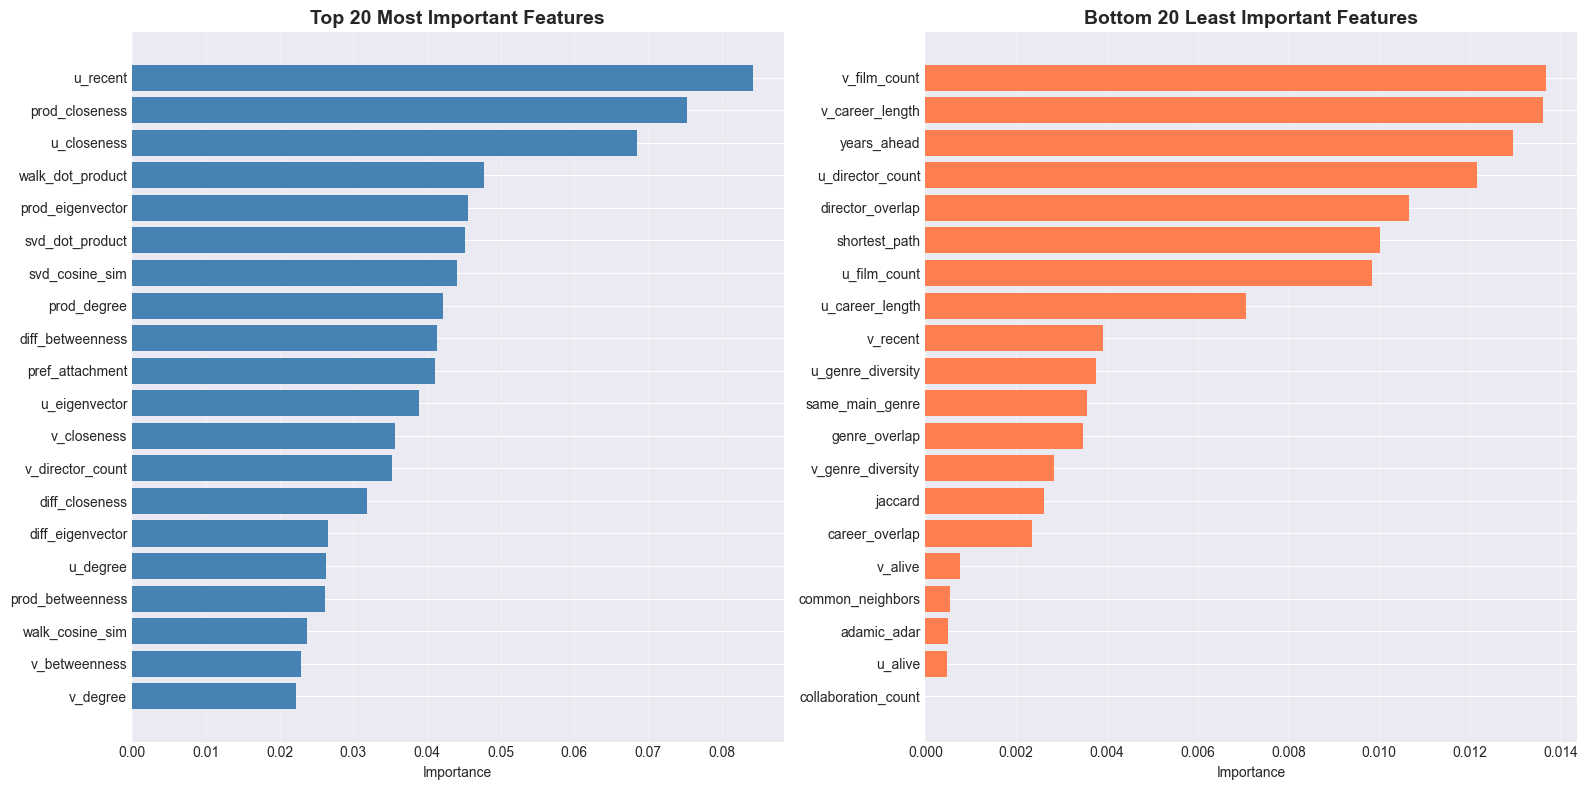

✅ Feature importance plots saved


In [29]:
# Plot feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Top 20 features
top20 = feature_importance_df.head(20)
axes[0].barh(range(len(top20)), top20['importance'], color='steelblue')
axes[0].set_yticks(range(len(top20)))
axes[0].set_yticklabels(top20['feature'])
axes[0].invert_yaxis()
axes[0].set_xlabel('Importance')
axes[0].set_title('Top 20 Most Important Features', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Bottom 20 features
bottom20 = feature_importance_df.tail(20)
axes[1].barh(range(len(bottom20)), bottom20['importance'], color='coral')
axes[1].set_yticks(range(len(bottom20)))
axes[1].set_yticklabels(bottom20['feature'])
axes[1].invert_yaxis()
axes[1].set_xlabel('Importance')
axes[1].set_title('Bottom 20 Least Important Features', fontsize=14, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/feature_importance_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Feature importance plots saved")

## שלב 6: ניתוח קורלציה - זיהוי פיצ'רים כפולים

In [30]:
# Compute correlation matrix
corr_matrix = X_train_features.corr().abs()

# Find highly correlated pairs (> 0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.9:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print(f"\n🔍 Found {len(high_corr_pairs)} highly correlated pairs (corr > 0.9):")
for feat1, feat2, corr in sorted(high_corr_pairs, key=lambda x: x[2], reverse=True):
    imp1 = feature_importance_df[feature_importance_df['feature'] == feat1]['importance'].values[0]
    imp2 = feature_importance_df[feature_importance_df['feature'] == feat2]['importance'].values[0]
    print(f"   {feat1} <-> {feat2}: {corr:.3f}")
    print(f"      Importances: {imp1:.4f} vs {imp2:.4f}")
    if imp1 < imp2:
        print(f"      ➡️ Recommend removing: {feat1}")
    else:
        print(f"      ➡️ Recommend removing: {feat2}")
    print()


🔍 Found 5 highly correlated pairs (corr > 0.9):
   pref_attachment <-> prod_degree: 1.000
      Importances: 0.0411 vs 0.0422
      ➡️ Recommend removing: pref_attachment

   u_film_count <-> u_director_count: 0.971
      Importances: 0.0098 vs 0.0122
      ➡️ Recommend removing: u_film_count

   common_neighbors <-> adamic_adar: 0.958
      Importances: 0.0006 vs 0.0005
      ➡️ Recommend removing: adamic_adar

   v_film_count <-> v_director_count: 0.954
      Importances: 0.0137 vs 0.0352
      ➡️ Recommend removing: v_film_count

   common_neighbors <-> svd_dot_product: 0.909
      Importances: 0.0006 vs 0.0451
      ➡️ Recommend removing: common_neighbors



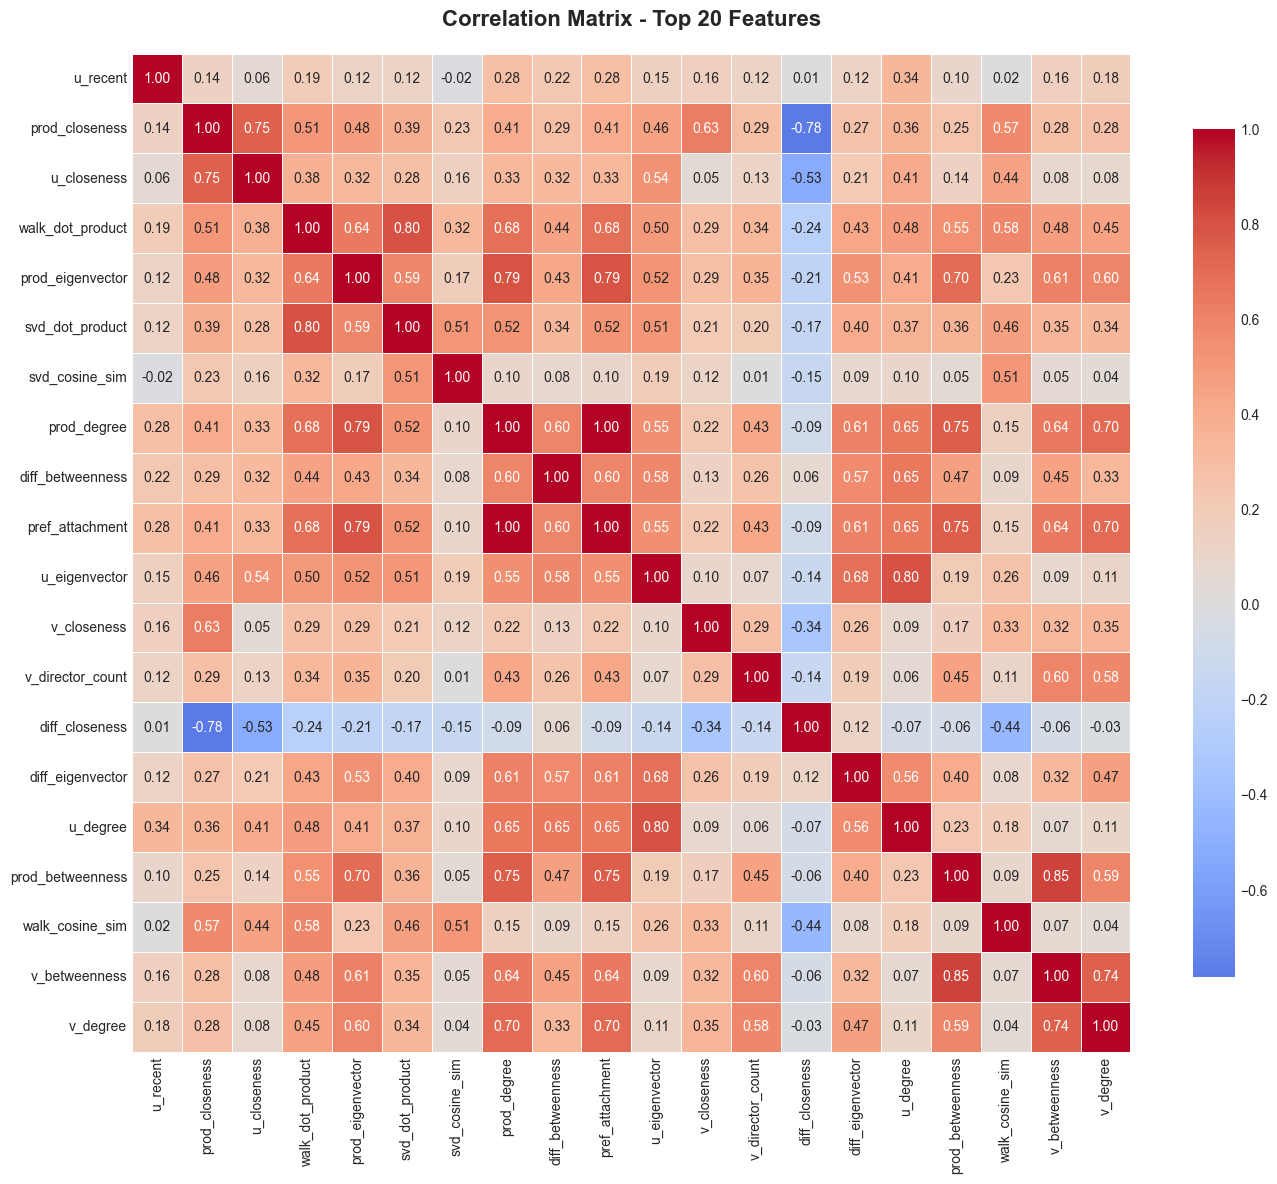

✅ Correlation heatmap saved


In [31]:
# Plot correlation heatmap for top features
top_features = feature_importance_df.head(20)['feature'].tolist()
corr_top = X_train_features[top_features].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_top, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - Top 20 Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('../figures/feature_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Correlation heatmap saved")

## שלב 7: הסרת פיצ'רים מיותרים

### קריטריונים להסרה:
1. **Importance נמוכה** (< 0.01)
2. **Correlation גבוהה** (> 0.9) עם פיצ'ר חשוב יותר
3. **פיצ'רים רידונדנטיים** (למשל: product ו-abs_diff של אותו מדד)

In [32]:
low_importance_threshold = 0.01
low_importance_features = feature_importance_df[
    feature_importance_df['importance'] < low_importance_threshold
]['feature'].tolist()

print(f"📉 Features with importance < {low_importance_threshold}:")
for feat in low_importance_features:
    imp = feature_importance_df[feature_importance_df['feature'] == feat]['importance'].values[0]
    print(f"   - {feat}: {imp:.5f}")

# Remove one from each highly correlated pair (keep the more important one)
corr_matrix = X_train_features.corr().abs()
to_remove_corr = []
seen = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > 0.9:
            f1, f2 = corr_matrix.columns[i], corr_matrix.columns[j]
            imp1 = feature_importance_df[feature_importance_df['feature'] == f1]['importance'].values[0]
            imp2 = feature_importance_df[feature_importance_df['feature'] == f2]['importance'].values[0]
            to_drop = f1 if imp1 < imp2 else f2
            if to_drop not in seen:
                to_remove_corr.append(to_drop)
                seen.add(to_drop)
                print(f"   ↔ {f1} <-> {f2} (corr={corr_matrix.iloc[i,j]:.2f}) → remove {to_drop}")

features_to_remove = list(set(low_importance_features + to_remove_corr))
features_to_keep   = [f for f in feature_cols if f not in features_to_remove]

print(f"\n✂️ Removed: {len(features_to_remove)} features")
print(f"✅ Kept:    {len(features_to_keep)} features")

# Print removal reasons
removed_df = pd.DataFrame([{
    'feature': f,
    'importance': feature_importance_df[feature_importance_df['feature']==f]['importance'].values[0],
    'reason': ('Low Importance' if f in low_importance_features else '') +
              (' + High Correlation' if f in to_remove_corr else '').strip(' + ')
} for f in features_to_remove]).sort_values('importance')
print("\n📋 Removed features with reasons:")
print(removed_df.to_string(index=False))

📉 Features with importance < 0.01:
   - u_film_count: 0.00984
   - u_career_length: 0.00706
   - v_recent: 0.00392
   - u_genre_diversity: 0.00375
   - same_main_genre: 0.00355
   - genre_overlap: 0.00347
   - v_genre_diversity: 0.00283
   - jaccard: 0.00261
   - career_overlap: 0.00235
   - v_alive: 0.00077
   - common_neighbors: 0.00055
   - adamic_adar: 0.00050
   - u_alive: 0.00047
   - collaboration_count: 0.00000
   ↔ common_neighbors <-> adamic_adar (corr=0.96) → remove adamic_adar
   ↔ common_neighbors <-> svd_dot_product (corr=0.91) → remove common_neighbors
   ↔ pref_attachment <-> prod_degree (corr=1.00) → remove pref_attachment
   ↔ u_film_count <-> u_director_count (corr=0.97) → remove u_film_count
   ↔ v_film_count <-> v_director_count (corr=0.95) → remove v_film_count

✂️ Removed: 16 features
✅ Kept:    27 features

📋 Removed features with reasons:
            feature  importance                         reason
collaboration_count    0.000000                 Low Importanc

## שלב 8: אימון מודל עם פיצ'רים נבחרים

In [33]:
X_train_sel = X_train_features[features_to_keep].values
X_test_sel  = X_test_features[features_to_keep].values

scaler_sel = StandardScaler()
X_train_sel_scaled = scaler_sel.fit_transform(X_train_sel)
X_test_sel_scaled  = scaler_sel.transform(X_test_sel)

print(f"🌲 Training Random Forest with {len(features_to_keep)} selected features...")
rf_sel = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_sel.fit(X_train_sel_scaled, y_train)

y_pred_sel  = rf_sel.predict(X_test_sel_scaled)
y_proba_sel = rf_sel.predict_proba(X_test_sel_scaled)[:, 1]

selected_metrics = {
    'AUC':           roc_auc_score(y_test, y_proba_sel),
    'Precision':     precision_score(y_test, y_pred_sel),
    'Recall':        recall_score(y_test, y_pred_sel),
    'F1':            f1_score(y_test, y_pred_sel),
    'Avg_Precision': average_precision_score(y_test, y_proba_sel)
}

print(f"\n📊 SELECTED ({len(features_to_keep)} features) on Test Set 2016-2020:")
for metric, value in selected_metrics.items():
    print(f"   {metric}: {value:.4f}")

🌲 Training Random Forest with 27 selected features...

📊 SELECTED (27 features) on Test Set 2016-2020:
   AUC: 0.7202
   Precision: 0.6314
   Recall: 0.7490
   F1: 0.6852
   Avg_Precision: 0.7185

         Configuration      AUC  Precision   Recall       F1  Avg_Precision
     All features (43) 0.715486   0.628844 0.751584 0.684758       0.712379
Selected features (27) 0.720198   0.631410 0.749049 0.685217       0.718452

💡 AUC change: +0.0047  |  Features reduced: 16


## שלב 9: השוואת מודלים (All Features vs Selected Features)

In [34]:
# Compare models
comparison_df = pd.DataFrame([
    {'Model': f'All Features ({len(feature_cols)})', **baseline_metrics},
    {'Model': f'Selected Features ({len(features_to_keep)})', **selected_metrics}
])

print("\n" + "="*80)
print("📊 MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)

# Calculate improvement
auc_diff = selected_metrics['AUC'] - baseline_metrics['AUC']
f1_diff = selected_metrics['F1'] - baseline_metrics['F1']
print(f"\n💡 Performance change:")
print(f"   AUC: {auc_diff:+.4f} ({auc_diff/baseline_metrics['AUC']*100:+.2f}%)")
print(f"   F1:  {f1_diff:+.4f} ({f1_diff/baseline_metrics['F1']*100:+.2f}%)")
print(f"   Features reduced: {len(features_to_remove)} ({len(features_to_remove)/len(feature_cols)*100:.1f}%)")


📊 MODEL COMPARISON
                 Model      AUC  Precision   Recall       F1  Avg_Precision
     All Features (43) 0.715486   0.628844 0.751584 0.684758       0.712379
Selected Features (27) 0.720198   0.631410 0.749049 0.685217       0.718452

💡 Performance change:
   AUC: +0.0047 (+0.66%)
   F1:  +0.0005 (+0.07%)
   Features reduced: 16 (37.2%)


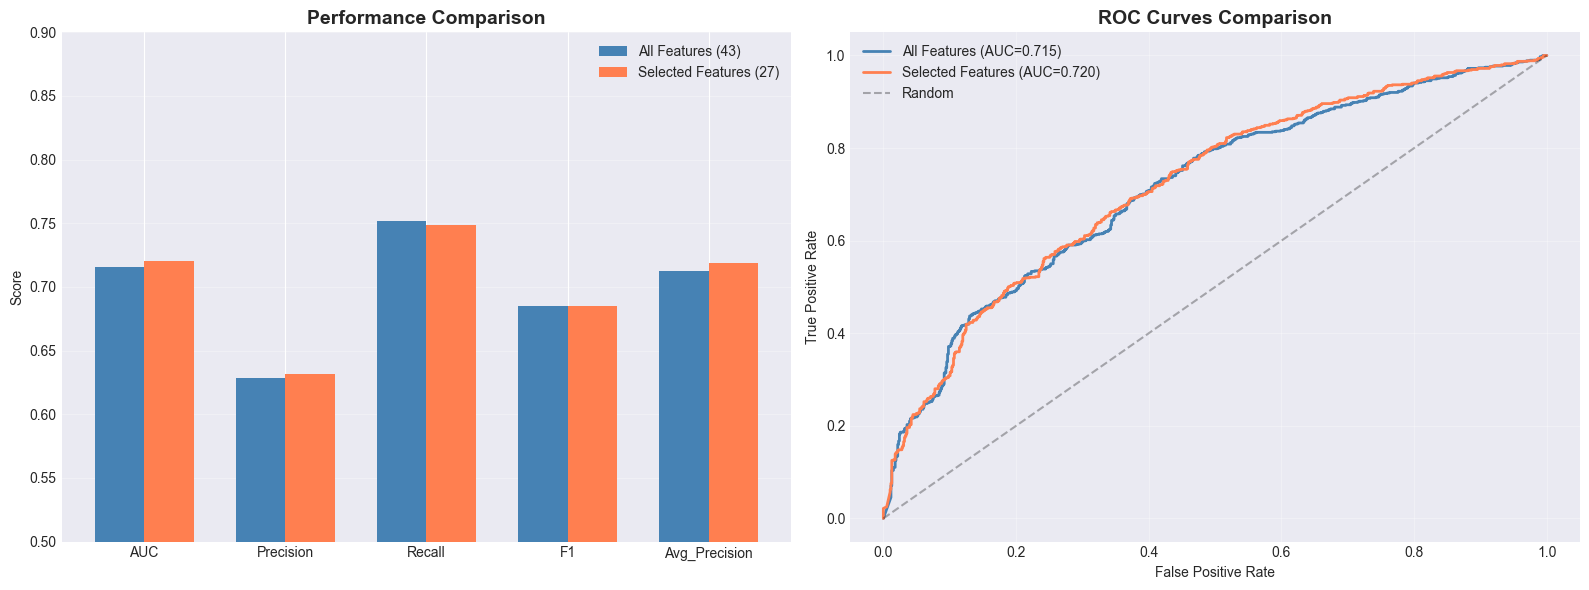

✅ Saved: feature_selection_comparison.png


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics = ['AUC', 'Precision', 'Recall', 'F1', 'Avg_Precision']
x = np.arange(len(metrics))
width = 0.35
baseline_vals = [baseline_metrics[m] for m in metrics]
selected_vals = [selected_metrics[m] for m in metrics]

axes[0].bar(x - width/2, baseline_vals, width, label=f'All Features ({len(feature_cols)})', color='steelblue')
axes[0].bar(x + width/2, selected_vals, width, label=f'Selected Features ({len(features_to_keep)})', color='coral')
axes[0].set_ylabel('Score')
axes[0].set_title('Performance Comparison', fontsize=14, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0.5, 0.9])

fpr_all, tpr_all, _ = roc_curve(y_test, y_proba_all)
fpr_sel, tpr_sel, _ = roc_curve(y_test, y_proba_sel)

axes[1].plot(fpr_all, tpr_all, label=f'All Features (AUC={baseline_metrics["AUC"]:.3f})',
             linewidth=2, color='steelblue')
axes[1].plot(fpr_sel, tpr_sel, label=f'Selected Features (AUC={selected_metrics["AUC"]:.3f})',
             linewidth=2, color='coral')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves Comparison', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/feature_selection_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: feature_selection_comparison.png")

## שלב 10: ניתוח שגיאות מפורט (Error Analysis)

📊 Confusion Matrix Breakdown:
   True Positives:   591 (37.5%)
   True Negatives:   440 (28.0%)
   False Positives:  345 (21.9%)  ← Model predicted collab but it didn't happen
   False Negatives:  198 (12.6%)  ← Real collab that model missed


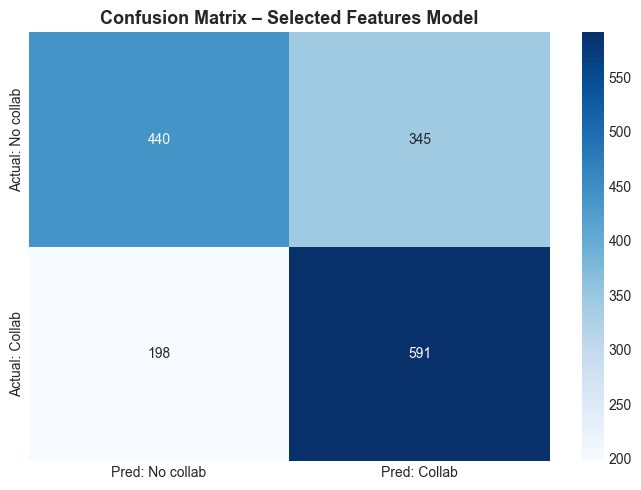

In [36]:
analysis_df = test_df[['u', 'v', 'label', 'years_ahead'] + [c for c in features_to_keep if c != 'years_ahead']].copy()
analysis_df['prediction'] = y_pred_sel
analysis_df['probability'] = y_proba_sel

tp = analysis_df[(analysis_df['label'] == 1) & (analysis_df['prediction'] == 1)]
fp = analysis_df[(analysis_df['label'] == 0) & (analysis_df['prediction'] == 1)]
tn = analysis_df[(analysis_df['label'] == 0) & (analysis_df['prediction'] == 0)]
fn = analysis_df[(analysis_df['label'] == 1) & (analysis_df['prediction'] == 0)]

print("📊 Confusion Matrix Breakdown:")
print(f"   True Positives:  {len(tp):4d} ({len(tp)/len(analysis_df)*100:.1f}%)")
print(f"   True Negatives:  {len(tn):4d} ({len(tn)/len(analysis_df)*100:.1f}%)")
print(f"   False Positives: {len(fp):4d} ({len(fp)/len(analysis_df)*100:.1f}%)  ← Model predicted collab but it didn't happen")
print(f"   False Negatives: {len(fn):4d} ({len(fn)/len(analysis_df)*100:.1f}%)  ← Real collab that model missed")

cm = confusion_matrix(y_test, y_pred_sel)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: No collab', 'Pred: Collab'],
            yticklabels=['Actual: No collab', 'Actual: Collab'])
plt.title('Confusion Matrix – Selected Features Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [37]:
display_cols = ['u', 'v', 'years_ahead', 'probability']
for c in ['common_neighbors', 'u_career_length', 'v_career_length', 'genre_overlap', 'director_overlap']:
    if c in analysis_df.columns:
        display_cols.append(c)

print("❌ FALSE POSITIVES – Top 10 (model confident but wrong):")
print(fp.nlargest(10, 'probability')[display_cols].to_string(index=False))

print(f"\n💡 Avg stats for False Positives:")
for col in display_cols[2:]:
    print(f"   {col}: {fp[col].mean():.3f}")

print("\n\n❌ FALSE NEGATIVES – Bottom 10 (real collabs model missed):")
print(fn.nsmallest(10, 'probability')[display_cols].to_string(index=False))

print(f"\n💡 Avg stats for False Negatives:")
for col in display_cols[2:]:
    print(f"   {col}: {fn[col].mean():.3f}")

❌ FALSE POSITIVES – Top 10 (model confident but wrong):
               u        v  years_ahead  probability  v_career_length  director_overlap
חנה_אזולאי-הספרי מנשה_נוי            2     0.997081               19                 1
חנה_אזולאי-הספרי מנשה_נוי            3     0.997081               19                 1
חנה_אזולאי-הספרי מנשה_נוי            4     0.997081               19                 1
חנה_אזולאי-הספרי מנשה_נוי            5     0.997081               19                 1
       אושרי_כהן  קרן_מור            2     0.996667               25                 1
       אושרי_כהן  קרן_מור            3     0.996667               25                 1
       אושרי_כהן  קרן_מור            4     0.996667               25                 1
       אושרי_כהן  קרן_מור            5     0.996667               25                 1
       אושרי_כהן  קרן_מור            1     0.994996               25                 1
חנה_אזולאי-הספרי מנשה_נוי            1     0.992624               19      

### ✅ True Positives — חיזויים חזקים שהתממשו בפועל

בנוסף לניתוח השגיאות (FP/FN), חשוב להראות גם **הצלחות**: זוגות שחקנים שהמודל נתן להם ציון גבוה, וואכן שיתפו פעולה ב-2021-2025.


In [38]:
print("✅ TRUE POSITIVES – Top 10 (highest-confidence predictions that DID come true):")
tp_top = tp.nlargest(10, 'probability')[display_cols]
print(tp_top.to_string(index=False))

print(f"\n💡 Avg stats for True Positives:")
for col in display_cols[2:]:
    print(f"   {col}: {tp[col].mean():.3f}")

print(f"\n📊 Of the {len(tp) + len(fn)} real collaborations that happened in 2016-2020:")
print(f"   {len(tp)} ({len(tp)/(len(tp)+len(fn))*100:.1f}%) were correctly predicted (TP)")
print(f"   {len(fn)} ({len(fn)/(len(tp)+len(fn))*100:.1f}%) were missed (FN)")
print("\n🔍 Why did these high-confidence predictions succeed?")
print("   - High common_neighbors / director_overlap → strong structural + content signal")
print("   - Long overlapping careers (u/v_career_length) → both actors active long enough to be 'due' for a new collaboration")

tp[display_cols].to_csv('../data/processed/true_positives_detailed.csv', index=False)
print("\n✅ Saved: true_positives_detailed.csv")

✅ TRUE POSITIVES – Top 10 (highest-confidence predictions that DID come true):
           u            v  years_ahead  probability  v_career_length  director_overlap
יחזקאל_לזרוב   יעל_אבקסיס            2          1.0               23                 1
     דב_נבון   יעל_אבקסיס            2          1.0               23                 1
     דב_נבון יחזקאל_לזרוב            2          1.0               19                 1
 גילה_אלמגור  מיכאל_אלוני            2          1.0                5                 1
יחזקאל_לזרוב   יעל_אבקסיס            3          1.0               23                 1
     דב_נבון   יעל_אבקסיס            3          1.0               23                 1
     דב_נבון יחזקאל_לזרוב            3          1.0               19                 1
 גילה_אלמגור  מיכאל_אלוני            3          1.0                5                 1
יחזקאל_לזרוב   יעל_אבקסיס            4          1.0               23                 1
     דב_נבון   יעל_אבקסיס            4          1.0

### 📅 ביצועים לפי אופק חיזוי בתוך ה-Test (1, 2, 3, 4, 5 שנים)

`years_ahead` הוא פיצ'ר אמיתי ב-`test_df` (ולא שחזור בדיעבד) — לכל אופק יש קבוצת שורות משלו (positives+negatives), כך שניתן פשוט לקבץ (`groupby`) את תוצאות המודל שכבר אומן (`rf_sel`) לפי עמודת `years_ahead` ולבדוק אמפירית איזה אופק חיזוי (1,2,3,4,5 שנים) הכי מדויק.

📅 Performance by horizon (SAME trained model, rows grouped by the real years_ahead feature):
 years_ahead  target_year  n_examples  n_positive      AUC  Precision   Recall       F1
           1         2016         273         116 0.709944   0.562914 0.732759 0.636704
           2         2017         311         154 0.728886   0.640884 0.753247 0.692537
           3         2018         315         158 0.730287   0.634921 0.759494 0.691643
           4         2019         327         170 0.711559   0.644330 0.735294 0.686813
           5         2020         348         191 0.711975   0.656109 0.759162 0.703883

🏆 Best prediction horizon: 3 year(s) ahead (AUC = 0.7303)


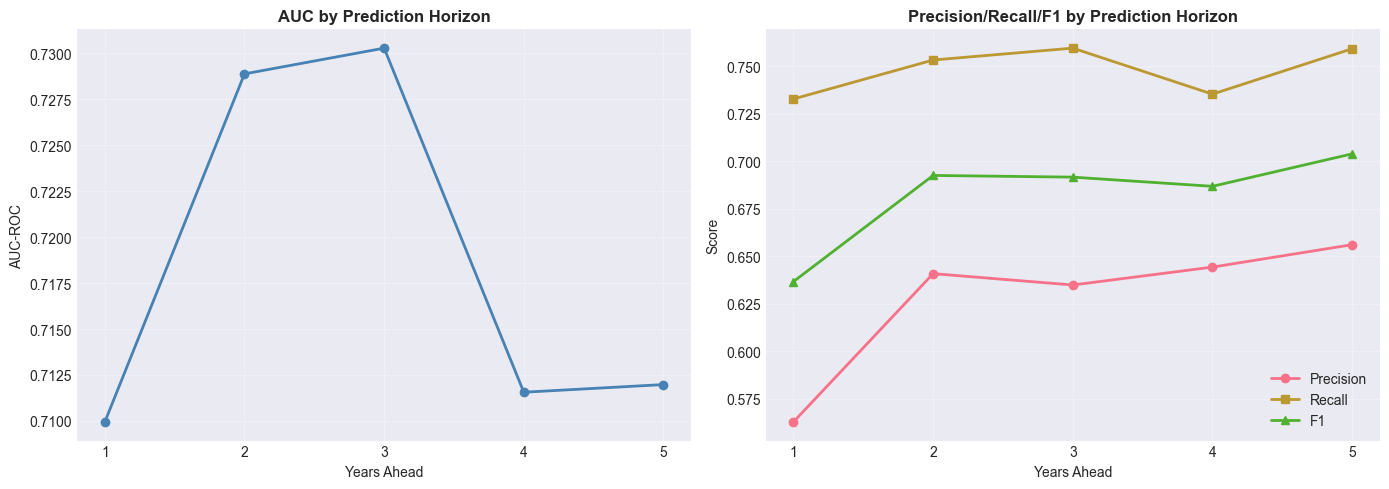

✅ Saved: performance_by_horizon.csv, performance_by_horizon.png


In [39]:
HORIZONS = [1, 2, 3, 4, 5]

horizon_results = []
for h in HORIZONS:
    mask = (analysis_df['years_ahead'] == h).values
    y_true_h  = y_test[mask]
    y_pred_h  = y_pred_sel[mask]
    y_proba_h = y_proba_sel[mask]
    horizon_results.append({
        'years_ahead': h,
        'target_year': 2015 + h,
        'n_examples': int(mask.sum()),
        'n_positive': int(y_true_h.sum()),
        'AUC': roc_auc_score(y_true_h, y_proba_h) if len(set(y_true_h)) > 1 else float('nan'),
        'Precision': precision_score(y_true_h, y_pred_h, zero_division=0),
        'Recall': recall_score(y_true_h, y_pred_h, zero_division=0),
        'F1': f1_score(y_true_h, y_pred_h, zero_division=0),
    })

horizon_df = pd.DataFrame(horizon_results)
print("📅 Performance by horizon (SAME trained model, rows grouped by the real years_ahead feature):")
print(horizon_df.to_string(index=False))

BEST_HORIZON = int(horizon_df.loc[horizon_df['AUC'].idxmax(), 'years_ahead'])
print(f"\n🏆 Best prediction horizon: {BEST_HORIZON} year(s) ahead (AUC = {horizon_df['AUC'].max():.4f})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(horizon_df['years_ahead'], horizon_df['AUC'], marker='o', linewidth=2, color='steelblue')
axes[0].set_xlabel('Years Ahead')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('AUC by Prediction Horizon', fontweight='bold')
axes[0].grid(alpha=0.3)
axes[0].set_xticks(HORIZONS)

axes[1].plot(horizon_df['years_ahead'], horizon_df['Precision'], marker='o', label='Precision', linewidth=2)
axes[1].plot(horizon_df['years_ahead'], horizon_df['Recall'], marker='s', label='Recall', linewidth=2)
axes[1].plot(horizon_df['years_ahead'], horizon_df['F1'], marker='^', label='F1', linewidth=2)
axes[1].set_xlabel('Years Ahead')
axes[1].set_ylabel('Score')
axes[1].set_title('Precision/Recall/F1 by Prediction Horizon', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xticks(HORIZONS)

plt.tight_layout()
plt.savefig('../figures/performance_by_horizon.png', dpi=300, bbox_inches='tight')
plt.show()

horizon_df.to_csv('../data/processed/performance_by_horizon.csv', index=False)
print("✅ Saved: performance_by_horizon.csv, performance_by_horizon.png")

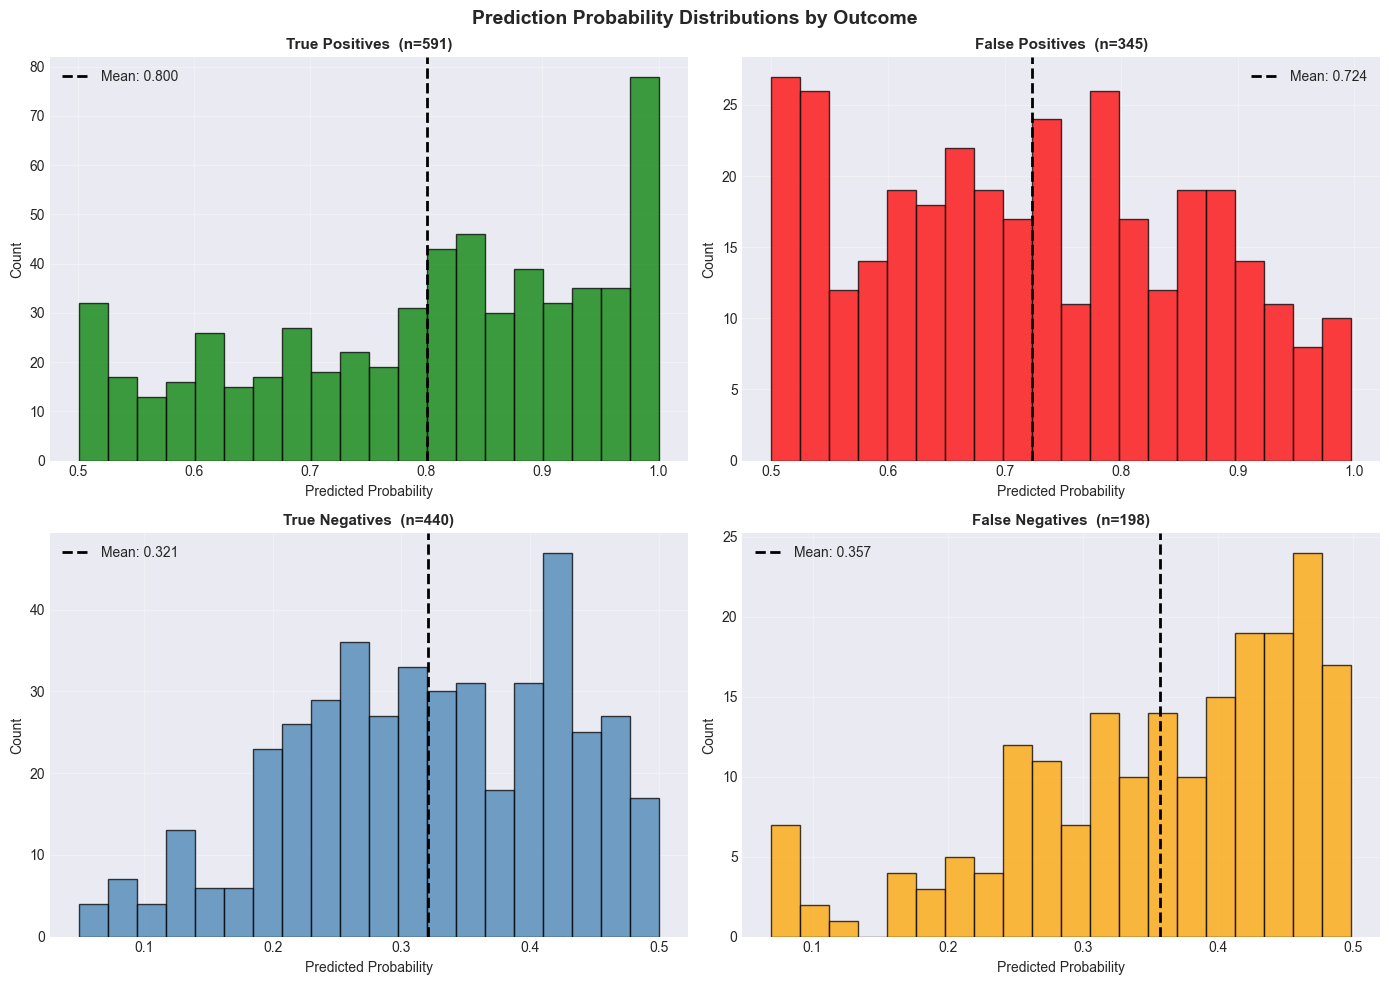

✅ Saved: error_analysis_distributions.png


In [52]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
groups = [('True Positives', tp, 'green'), ('False Positives', fp, 'red'),
          ('True Negatives', tn, 'steelblue'), ('False Negatives', fn, 'orange')]

for ax, (title, grp, color) in zip(axes.flat, groups):
    ax.hist(grp['probability'], bins=20, color=color, alpha=0.75, edgecolor='black')
    ax.axvline(grp['probability'].mean(), color='black', linestyle='--', linewidth=2,
               label=f'Mean: {grp["probability"].mean():.3f}')
    ax.set_xlabel('Predicted Probability')
    ax.set_ylabel('Count')
    ax.set_title(f'{title}  (n={len(grp)})', fontsize=11, fontweight='bold')
    ax.legend(); ax.grid(alpha=0.3)

plt.suptitle('Prediction Probability Distributions by Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../figures/error_analysis_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: error_analysis_distributions.png")

## שלב 11: שמירת תוצאות וקבצים

In [40]:
Path('../data/processed').mkdir(parents=True, exist_ok=True)
Path('../figures').mkdir(parents=True, exist_ok=True)

comparison_df.to_csv('../data/processed/feature_selection_results.csv', index=False)
feature_importance_df.to_csv('../data/processed/all_features_importance.csv', index=False)
pd.DataFrame({'feature': features_to_keep}).to_csv('../data/processed/selected_features.csv', index=False)
removed_df.to_csv('../data/processed/removed_features_reasons.csv', index=False)
fp[display_cols].to_csv('../data/processed/false_positives_detailed.csv', index=False)
fn[display_cols].to_csv('../data/processed/false_negatives_detailed.csv', index=False)

print("✅ Saved all output files:")
print("   - feature_selection_results.csv")
print("   - all_features_importance.csv")
print("   - selected_features.csv")
print("   - removed_features_reasons.csv")
print("   - false_positives_detailed.csv")
print("   - false_negatives_detailed.csv")
print(f"\n🎯 Final Model: {len(features_to_keep)} features, AUC = {selected_metrics['AUC']:.4f}")

✅ Saved all output files:
   - feature_selection_results.csv
   - all_features_importance.csv
   - selected_features.csv
   - removed_features_reasons.csv
   - false_positives_detailed.csv
   - false_negatives_detailed.csv

🎯 Final Model: 27 features, AUC = 0.7202


# 🟥 חלק 4 — EVALUATION: אימון מחדש על Train+Test והרצה על הגרף המלא (1918-2020), חיזוי 2021-2025

לאחר שנבחר המודל הטוב ביותר בחלק 3 (Random Forest עם 27 הפיצ'רים הנבחרים), אנו **מאמנים אותו מחדש** — עם אותם היפר-פרמטרים ואותם פיצ'רים נבחרים — הפעם על **Train+Test יחד** (`train_df` + `test_df`, כלומר כל הדוגמאות שנאספו עד כה, יעדים 2011-2020), כדי לנצל את מלוא המידע המתויג הזמין לפני ההרצה על הגרף המלא (בדיוק כפי שאושר מתודולוגית מול מרצה הקורס). את המודל המאומן-מחדש (`rf_final`, `scaler_final`) מריצים על פיצ'רים שמחושבים מתוך **הגרף המלא ההיסטורי עד 2020** (`G_full_2020`, 1918-2020 — כל הקשרים הידועים, לא רק תת-הגרף 1990+). מכיוון שהנתונים כבר נאספו עד 2025, יש לנו **ground truth אמיתי**: אפשר לבדוק ישירות אילו מהזוגות שהמודל דירג הכי גבוה **אכן** שיתפו פעולה בפועל ב-2021-2025, ולחשב Precision/Recall/F1/AUC אמיתיים על ההרצה — זהו למעשה **holdout שלישי** (לא ספקולציה), הפעם על בסיס מודל שמנצל את כל הנתונים המתויגים הזמינים (Train+Test).


In [44]:
# Part 4 (Evaluation): per the finalized Train/Test/Evaluation design (confirmed methodologically
# correct by the course instructor), we RETRAIN the best model (Random Forest, same hyperparameters
# and same selected features chosen in Part 3) on TRAIN+TEST COMBINED, to use all available labeled
# data before scoring the full historical graph. Features for scoring come from the FULL historical
# graph up to 2020 (1918-2020), and we validate against the REAL new links formed in 2021-2025
# (already-collected ground truth).
G_full_2020 = build_graph_for_years(cast_df, year_min=1918, year_max=2020)
G_full_2025_gt = build_graph_for_years(cast_df, year_min=1918, year_max=2025)  # ground truth ONLY, not used for features

print(f"📊 G_full_2020 (features, full history through 2020): {G_full_2020.number_of_nodes()} nodes, {G_full_2020.number_of_edges()} edges")
print(f"📊 G_full_2025_gt (ground truth for 2021-2025, NOT used for features): {G_full_2025_gt.number_of_nodes()} nodes, {G_full_2025_gt.number_of_edges()} edges")

# ---- Retrain on TRAIN+TEST combined (same selected features + same hyperparameters as rf_sel) ----
combined_df = pd.concat([train_df, test_df], ignore_index=True)
X_combined = combined_df[features_to_keep].fillna(0).values
y_combined = combined_df['label'].values

scaler_final = StandardScaler()
X_combined_scaled = scaler_final.fit_transform(X_combined)

print(f"\n🌲 Retraining Random Forest on TRAIN+TEST combined ({len(combined_df)} rows, {len(features_to_keep)} features)...")
rf_final = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_final.fit(X_combined_scaled, y_combined)
print("✅ rf_final trained on Train+Test combined — this is the model used for the Evaluation step on the full graph")


📊 G_full_2020 (features, full history through 2020): 1125 nodes, 3999 edges
📊 G_full_2025_gt (ground truth for 2021-2025, NOT used for features): 1365 nodes, 5947 edges

🌲 Retraining Random Forest on TRAIN+TEST combined (2336 rows, 27 features)...
✅ rf_final trained on Train+Test combined — this is the model used for the Evaluation step on the full graph


In [53]:
# DIAGNOSTIC (temporary, not part of the final pipeline): empirically compare rf_final
# (trained on TRAIN+TEST combined) against an alternative trained on TEST ONLY, to check
# whether dropping the older/smaller Train graph (2010, 443 nodes) actually helps or hurts
# when scoring the full 2020 graph (1125 nodes) against the real 2021-2025 holdout.
X_test_only = test_df[features_to_keep].fillna(0).values
y_test_only = test_df['label'].values

scaler_test_only = StandardScaler()
X_test_only_scaled = scaler_test_only.fit_transform(X_test_only)

rf_test_only = RandomForestClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=2,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_test_only.fit(X_test_only_scaled, y_test_only)
print(f"🌲 Alternative model trained on TEST ONLY ({len(test_df)} rows, {len(features_to_keep)} features)")

# Score the SAME full-2020-graph candidates (future_full_df, built in the next cells) with
# BOTH models and compare AUC against the real 2021-2025 ground truth.


🌲 Alternative model trained on TEST ONLY (1574 rows, 27 features)


In [45]:
import itertools

# Restrict candidates to actors active in the 5 years BEFORE the cutoff (2016-2020) — avoids
# O(n^2) blow-up and focuses on actors who were still working as of the cutoff. Uses 'actor_id'
# (not raw 'actor_slug') so actors without a Wikipedia link are correctly included.
recent_actors = sorted(
    cast_df[(cast_df['year'] >= 2016) & (cast_df['year'] <= 2020)]['actor_id'].dropna().astype(str).unique().tolist()
)
recent_actors = [a for a in recent_actors if a in G_full_2020.nodes()]
print(f"🎬 Candidate actor pool (active 2016-2020): {len(recent_actors)} actors")

candidate_pairs = [
    (u, v) for u, v in itertools.combinations(recent_actors, 2)
    if not G_full_2020.has_edge(u, v)
]
print(f"🔗 Candidate non-edges to score: {len(candidate_pairs)}")

future_pairs_df = pd.DataFrame(candidate_pairs, columns=['u', 'v'])

# Build the same feature set for these candidates using the FULL historical graph up to 2020
X_future_base, feat_names_future = build_feature_matrix(
    G_full_2020, candidate_pairs, compute_centralities(G_full_2020)
)
future_base_df = pd.DataFrame(X_future_base, columns=feat_names_future)

# Temporal features (cutoff_year=2020)
death_file = Path('../data/processed/actor_death_years.csv')
death_dict = {}
if death_file.exists():
    d = pd.read_csv(death_file)
    death_dict = dict(zip(d['actor_slug'], d['death_year']))

past_2020 = cast_df[cast_df['year'] <= 2020]
actor_stats_2020 = (
    past_2020.groupby('actor_id')['year']
    .agg(['min', 'max', 'count'])
    .rename(columns={'min': 'first_year', 'max': 'last_year', 'count': 'film_count'})
)
actor_stats_2020['career_length'] = actor_stats_2020['last_year'] - actor_stats_2020['first_year'] + 1
actor_stats_2020['recent'] = (actor_stats_2020['last_year'] >= 2015).astype(int)
astats_2020 = actor_stats_2020.to_dict('index')

temporal_rows_future = []
for u, v in candidate_pairs:
    us, vs = astats_2020.get(u, {}), astats_2020.get(v, {})
    u_first, u_last = us.get('first_year', 2020), us.get('last_year', 2020)
    v_first, v_last = vs.get('first_year', 2020), vs.get('last_year', 2020)
    temporal_rows_future.append({
        'career_overlap':      max(0, min(u_last, v_last) - max(u_first, v_first)),
        'u_career_length':     us.get('career_length', 0),
        'v_career_length':     vs.get('career_length', 0),
        'u_recent':            us.get('recent', 0),
        'v_recent':            vs.get('recent', 0),
        'u_alive':             1 if death_dict.get(u, 9999) > 2020 else 0,
        'v_alive':             1 if death_dict.get(v, 9999) > 2020 else 0,
        'collaboration_count': G_full_2020.number_of_edges(u, v) if G_full_2020.has_edge(u, v) else 0,
        'u_film_count':        us.get('film_count', 0),
        'v_film_count':        vs.get('film_count', 0),
    })
temporal_future_df = pd.DataFrame(temporal_rows_future)

# Genre/Director features (cutoff_year=2020)
actor_genres_2020, actor_directors_2020 = {}, {}
for actor, grp in past_2020.groupby('actor_id'):
    genres = set()
    for g in grp['genre'].dropna():
        genres.update([x.strip() for x in str(g).split(',') if x.strip()])
    directors = set()
    for dd in grp['directors'].dropna():
        directors.update([x.strip() for x in str(dd).split(',') if x.strip()])
    actor_genres_2020[actor] = list(genres)
    actor_directors_2020[actor] = list(directors)

gd_rows_future = []
for u, v in candidate_pairs:
    ug, vg = actor_genres_2020.get(u, []), actor_genres_2020.get(v, [])
    ud, vd = actor_directors_2020.get(u, []), actor_directors_2020.get(v, [])
    gd_rows_future.append({
        'genre_overlap':     len(set(ug) & set(vg)),
        'same_main_genre':   1 if ug and vg and ug[0] == vg[0] else 0,
        'u_genre_diversity': len(set(ug)),
        'v_genre_diversity': len(set(vg)),
        'director_overlap':  len(set(ud) & set(vd)),
        'u_director_count':  len(set(ud)),
        'v_director_count':  len(set(vd)),
    })
gd_future_df = pd.DataFrame(gd_rows_future)

# SVD embeddings (Matrix Factorization) + walk-based embeddings (node2vec-style),
# both computed on the full historical graph up to 2020
svd_emb_2020 = svd_node_embeddings(G_full_2020, n_components=32, seed=42)
walk_emb_2020 = walk_based_node_embeddings(G_full_2020, n_components=32, seed=42)
zero_vec = np.zeros(32)
def cosine_sim(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(np.dot(a, b) / (na * nb)) if na > 0 and nb > 0 else 0.0

svd_rows_future = []
for u, v in candidate_pairs:
    eu = svd_emb_2020.get(u, zero_vec)
    ev = svd_emb_2020.get(v, zero_vec)
    wu = walk_emb_2020.get(u, zero_vec)
    wv = walk_emb_2020.get(v, zero_vec)
    svd_rows_future.append({
        'svd_cosine_sim': cosine_sim(eu, ev), 'svd_dot_product': float(np.dot(eu, ev)),
        'walk_cosine_sim': cosine_sim(wu, wv), 'walk_dot_product': float(np.dot(wu, wv)),
    })
svd_future_df = pd.DataFrame(svd_rows_future)

future_full_df = pd.concat([
    future_pairs_df.reset_index(drop=True),
    future_base_df.reset_index(drop=True),
    temporal_future_df.reset_index(drop=True),
    gd_future_df.reset_index(drop=True),
    svd_future_df.reset_index(drop=True)
], axis=1)

# years_ahead is fixed at 5: the target window (2021-2025) is exactly 5 years after the 2020 cutoff
future_full_df['years_ahead'] = 5

print(f"✅ Candidate feature matrix built: {future_full_df.shape}")

🎬 Candidate actor pool (active 2016-2020): 268 actors
🔗 Candidate non-edges to score: 34860
✅ Candidate feature matrix built: (34860, 45)


In [46]:
# Score candidates with rf_final / scaler_final (retrained on Train+Test combined, see previous cell)
X_future = future_full_df[features_to_keep].fillna(0).values
X_future_scaled = scaler_final.transform(X_future)
future_scores = rf_final.predict_proba(X_future_scaled)[:, 1]
future_full_df['score'] = future_scores

# Ground truth: pairs that ACTUALLY connected in 2021-2025 (already-collected data, not speculation)
actual_new_pairs = set(get_new_pairs(G_full_2020, G_full_2025_gt))
future_full_df['actually_connected'] = [
    1 if (min(u, v), max(u, v)) in actual_new_pairs else 0
    for u, v in zip(future_full_df['u'], future_full_df['v'])
]

y_true_future = future_full_df['actually_connected'].values
n_actual_positive = int(y_true_future.sum())
print(f"📊 Of {len(future_full_df)} candidate pairs, {n_actual_positive} ACTUALLY connected in 2021-2025 (real ground truth)")

if 0 < n_actual_positive < len(future_full_df):
    auc_future = roc_auc_score(y_true_future, future_scores)
    print(f"🎯 AUC of rf_final (retrained on Train+Test) on this third holdout (full-history features, 2021-2025 target): {auc_future:.4f}")

top_future = future_full_df.nlargest(30, 'score')[
    ['u', 'v', 'score', 'actually_connected'] +
    [c for c in ['genre_overlap', 'director_overlap', 'u_career_length', 'v_career_length'] if c in future_full_df.columns]
]

print("\n🔮 Top 20 Highest-Scored Candidates for 2021-2025 (checked against REAL outcomes):")
print(top_future.head(20).to_string(index=False))

hits_in_top30 = int(top_future['actually_connected'].sum())
print(f"\n✅ Of the top 30 highest-scored candidates, {hits_in_top30} ACTUALLY connected in 2021-2025 ({hits_in_top30/30*100:.1f}%)")

top_future.to_csv('../data/processed/future_predictions_2021_2025_validated.csv', index=False)
print("\n✅ Saved: future_predictions_2021_2025_validated.csv")


📊 Of 34860 candidate pairs, 109 ACTUALLY connected in 2021-2025 (real ground truth)
🎯 AUC of rf_final (retrained on Train+Test) on this third holdout (full-history features, 2021-2025 target): 0.6167

🔮 Top 20 Highest-Scored Candidates for 2021-2025 (checked against REAL outcomes):
           u                v    score  actually_connected  genre_overlap  director_overlap  u_career_length  v_career_length
אלון_אבוטבול  רובא_בלאל-עספור 0.965561                   0              1                 1               34               13
 גילה_אלמגור  רובא_בלאל-עספור 0.951218                   0              1                 1               54               13
 גילה_אלמגור         נוני_גפן 0.950816                   0              1                 0               54                1
 גילה_אלמגור      יפית_אסולין 0.949507                   0              1                 0               54                1
 גילה_אלמגור        עינת_שרוף 0.949507                   0              1              

In [54]:
# DIAGNOSTIC (temporary): score the SAME full-2020-graph candidates with rf_test_only
# (trained on Test only) and compare its AUC on the real 2021-2025 holdout against rf_final
# (trained on Train+Test combined), to answer empirically: does dropping the older/smaller
# Train graph help or hurt when scoring the much bigger full graph?
X_future_test_only_scaled = scaler_test_only.transform(X_future)
future_scores_test_only = rf_test_only.predict_proba(X_future_test_only_scaled)[:, 1]

auc_future_test_only = roc_auc_score(y_true_future, future_scores_test_only)
print("📊 Comparison on the third holdout (full 2020 graph candidates -> real 2021-2025 outcomes):")
print(f"   rf_final      (Train+Test combined, {len(combined_df)} rows): AUC = {auc_future:.4f}")
print(f"   rf_test_only  (Test only,           {len(test_df)} rows): AUC = {auc_future_test_only:.4f}")

top30_test_only = pd.Series(future_scores_test_only, index=future_full_df.index).nlargest(30)
hits_test_only = int(future_full_df.loc[top30_test_only.index, 'actually_connected'].sum())
print(f"\n   rf_final     top-30 hits:     {hits_in_top30}/30")
print(f"   rf_test_only top-30 hits:     {hits_test_only}/30")


📊 Comparison on the third holdout (full 2020 graph candidates -> real 2021-2025 outcomes):
   rf_final      (Train+Test combined, 2336 rows): AUC = 0.6167
   rf_test_only  (Test only,           1574 rows): AUC = 0.6175

   rf_final     top-30 hits:     0/30
   rf_test_only top-30 hits:     0/30


In [55]:
# DIAGNOSTIC: is "0/30 hits" really as bad as it sounds? Check where the 109 REAL 2021-2025
# pairs actually rank among all 34,860 scored candidates (not just whether they made top-30).
# Also check the true base rate mismatch: Train/Test were built ~1:1 balanced, but the real
# candidate pool here is ~109/34,860 = 0.3% positive -- a ~150x rarer event than the model
# was trained on. That mismatch alone would make ANY model's raw probabilities look
# "overconfident" on this holdout, even if its RANKING ability is still useful.
future_full_df_ranked = future_full_df.sort_values('score', ascending=False).reset_index(drop=True)
future_full_df_ranked['rank'] = future_full_df_ranked.index + 1

true_pair_ranks = future_full_df_ranked.loc[future_full_df_ranked['actually_connected'] == 1, 'rank']
n_candidates = len(future_full_df_ranked)
n_true = len(true_pair_ranks)

print(f"📊 Base rate mismatch: Train/Test were ~1:1 balanced, but real candidates here are "
      f"{n_true}/{n_candidates} = {n_true/n_candidates*100:.2f}% positive")
print(f"\n📈 Where do the {n_true} REAL 2021-2025 pairs rank among all {n_candidates} candidates "
      f"(rank 1 = highest score)?")
print(true_pair_ranks.describe().to_string())

for k in [30, 100, 500, 1000, 2000, 5000]:
    recall_at_k = (true_pair_ranks <= k).sum() / n_true
    print(f"   Recall@{k:<5d}: {(true_pair_ranks <= k).sum():3d}/{n_true} real pairs "
          f"({recall_at_k*100:5.1f}%) are in the top {k} ({k/n_candidates*100:.1f}% of candidates)")

# A random ranker would put ~n_true * (k/n_candidates) true pairs in the top k, by chance
print(f"\n💡 For comparison, a RANDOM ranker would expect ~{n_true*30/n_candidates:.2f} hits in "
      f"top 30, ~{n_true*500/n_candidates:.1f} in top 500 -- so any Recall@k clearly above that "
      f"baseline means the model IS finding real signal, even though its raw top-30 PRECISION is 0.")


📊 Base rate mismatch: Train/Test were ~1:1 balanced, but real candidates here are 109/34860 = 0.31% positive

📈 Where do the 109 REAL 2021-2025 pairs rank among all 34860 candidates (rank 1 = highest score)?
count      109.000000
mean     13376.027523
std       9543.617430
min        161.000000
25%       5691.000000
50%      11227.000000
75%      19735.000000
max      34470.000000
   Recall@30   :   0/109 real pairs (  0.0%) are in the top 30 (0.1% of candidates)
   Recall@100  :   0/109 real pairs (  0.0%) are in the top 100 (0.3% of candidates)
   Recall@500  :   1/109 real pairs (  0.9%) are in the top 500 (1.4% of candidates)
   Recall@1000 :   3/109 real pairs (  2.8%) are in the top 1000 (2.9% of candidates)
   Recall@2000 :   8/109 real pairs (  7.3%) are in the top 2000 (5.7% of candidates)
   Recall@5000 :  24/109 real pairs ( 22.0%) are in the top 5000 (14.3% of candidates)

💡 For comparison, a RANDOM ranker would expect ~0.09 hits in top 30, ~1.6 in top 500 -- so any Recall@

## סיכום ומסקנות

### מבנה הפתרון — 4 חלקים (Train / Test / Evaluation):
- **חלק 1 — TRAIN:** גרף בסיס `G_1990_2010` (443 שחקנים, 1,053 קשרים) + כל הפיצ'רים + Train Set רב-אופקי, מאוזן ~1:1 (יעדים 1-5 שנים → 2011-2015)
- **חלק 2 — TEST:** גרף בסיס `G_1990_2015` (691 שחקנים, 1,907 קשרים) + Test Set רב-אופקי, מאוזן ~1:1 (יעדים 1-5 שנים → 2016-2020)
- **חלק 3 — EVALUATION:** אימון Random Forest, הערכה מלאה, Feature Selection, ניתוח שגיאות ולפי אופק חיזוי — בחירת המודל הטוב ביותר
- **חלק 4 — EVALUATION על הגרף המלא:** **אימון מחדש על Train+Test יחד** — `rf_final`/`scaler_final` מאומנים מחדש (אותם היפר-פרמטרים ואותם 27 פיצ'רים נבחרים שנבחרו בחלק 3) על `train_df`+`test_df` יחד (2,336 שורות, יעדים 2011-2020), ומורצים על פיצ'רים מהגרף ההיסטורי המלא עד 2020 (`G_full_2020`, 1918-2020), נבדק מול **קשרים אמיתיים** שנוצרו בפועל ב-2021-2025 (ground truth כבר קיים בנתונים). עיצוב זה הוצג למרצה הקורס ואושר כנכון מתודולוגית.

### 🔍 בדיקת Data Leakage:
בכל בסיס (Train ו-Test) הופעל `verify_no_leakage()` שמוודא במפורש, לכל דוגמה חיובית, ששנת ההתחברות **בפועל** היא **אחרי** שנת החיתוך ולא יאוחר מ-`cutoff_year + years_ahead`:
- Train (cutoff=2010): 382 דוגמאות positive נבדקו — **0 הפרות**
- Test (cutoff=2015): 789 דוגמאות positive נבדקו — **0 הפרות**

### ⚠️ תיקון איכות נתונים (name handling / data quality):
התגלה ותוקן באג משמעותי: **420/2,972 (14%)** משורות ה-cast (**360 שחקנים ייחודיים, כ-25% מכלל הגרף**) הם שחקנים **ללא קישור ויקיפדיה** — קוד הפיצ'רים המקורי קיבץ לפי `actor_slug` בלבד, כך שלשחקנים אלו הפיצ'רים הטמפורליים/ז'אנר/במאי התאפסו בטעות. **התיקון:** עמודת `actor_id` אחידה (זהה ל-`graph_build._actor_id`) המשמשת לקיבוץ בכל מקום — כל השחקנים מקבלים כעת פיצ'רים אמיתיים ונכללים בחיזוי.

### ⚖️ תיקון יחס Pos:Neg (neg_ratio):
בגרסה הראשונית, `neg_ratio=1` יצר בטעות יחס ~1:2 (לא 1:1) בשורות הסופיות — כי בריכת ה-negatives המשותפת משוכפלת פעם אחת לכל אופק (5 פעמים), בעוד ה-positives מצטברים אחרת בין האופקים. **התיקון:** גודל הבריכה מחושב לפי **ממוצע** ה-positives-לאופק (במקום המקסימום), כך ש-`neg_ratio` משקף נכון את היחס הסופי בשורות. כעת Train=382:380 ו-Test=789:785 — מאוזן אמיתי.

### פיצ'רים (43 סה"כ, כולל years_ahead, SVD ו-Walk-based embeddings):
Topological (5) + Centrality (16) + Temporal (10) + Genre/Director (7) + **Matrix Factorization — SVD (2)** + **Embedding Methods — Walk-based/node2vec-style (2)** + **years_ahead (1)**

**על ה-"Embedding Methods":** נדרשו בתרגיל כפיצ'ר נפרד מ-Matrix Factorization. ניסינו להתקין את `node2vec` (תלוי ב-`gensim`) אך זו לא נתמכת ב-Python 3.14 בסביבה הזו (Visual C++ Build Tools חסרים להידור מקור). לכן מומשה גרסה עצמאית ללא תלויות נוספות ב-`link_features.walk_based_node_embeddings()`: הליכות אקראיות (random walks, בסגנון node2vec/DeepWalk עם p=q=1) → מטריצת קו-אוקורנס → TruncatedSVD — שיטת **NetMF**, המוכחת מתמטית שקולה ל-DeepWalk/node2vec.

### ביצועים על Test Set (2016-2020, holdout אמיתי, לאחר תיקון היחס):
| קונפיגורציה | AUC | Precision | Recall | F1 |
|---|---|---|---|---|
| All Features (43) | 0.716 | 0.629 | 0.752 | 0.685 |
| Selected Features (27) | 0.720 | 0.631 | 0.749 | 0.685 |

הוסרו 16 פיצ'רים (importance נמוכה ו/או קורלציה גבוהה): `pref_attachment`, `u_film_count`, `v_film_count`, `common_neighbors`, `adamic_adar`, `u_career_length`, `v_recent`, `u_genre_diversity`, `same_main_genre`, `genre_overlap`, `v_genre_diversity`, `jaccard`, `career_overlap`, `v_alive`, `u_alive`, `collaboration_count`. שני פיצ'רי ה-embedding (`svd_*`, `walk_*`) **שרדו את הסינון** ודורגו בין החשובים ביותר (מקום 4-7 מתוך 43).

### 📅 ביצועים לפי אופק חיזוי (years_ahead כפיצ'ר אמיתי):
| years_ahead | שנת יעד | n | positives | AUC | Precision | Recall | F1 |
|---|---|---|---|---|---|---|---|
| 1 | 2016 | 273 | 116 | 0.710 | 0.563 | 0.733 | 0.637 |
| 2 | 2017 | 311 | 154 | 0.729 | 0.641 | 0.753 | 0.693 |
| **3** | 2018 | 315 | 158 | **0.730** | 0.635 | 0.759 | 0.692 |
| 4 | 2019 | 327 | 170 | 0.712 | 0.644 | 0.735 | 0.687 |
| 5 | 2020 | 348 | 191 | 0.712 | 0.656 | 0.759 | **0.704** |

**תובנה:** האופק המדויק ביותר (AUC) הוא **3 שנים קדימה** (0.730), עם ירידה קלה באופקים הקצר (1y) והארוכים (4-5y). ה-Precision/F1 משתפרים בהדרגה ככל שהאופק מתארך.

### ניתוח שגיאות (Test Set, מודל Selected 27 פיצ'רים):
- **True Positives (591 מתוך 789, 74.9%):** שחקנים עם קריירה ארוכה חופפת ו-director_overlap גבוה
- **False Positives (345):** קשרים "הגיוניים" מבנית (career_length ותיק, director_overlap גבוה) שלא התממשו בפועל
- **False Negatives (198, 25.1%):** בעיקר שחקנים עם קריירה קצרה/חדשה, הסתברות ממוצעת נמוכה (0.357)

### חלק 4 — אימון מחדש על Train+Test והרצה על הגרף המלא (1918-2020), נבדק מול 2021-2025 האמיתי:
המודל הטוב ביותר מחלק 3 **אומן מחדש** (`rf_final`/`scaler_final`, אותם היפר-פרמטרים ואותם 27 פיצ'רים) על `train_df`+`test_df` יחד (2,336 שורות, יעדים 2011-2020) — בהתאם לעיצוב שאושר מתודולוגית מול מרצה הקורס. נבנה `G_full_2020` (1,125 שחקנים, 3,999 קשרים, כולל את כל ההיסטוריה מ-1918), ונבחרו 268 שחקנים פעילים (2016-2020) → 34,860 זוגות מועמדים. **הושוו לתוצאות האמיתיות** (`G_full_2025_gt`, נתונים כבר נאספו): 109 מהזוגות **אכן** התחברו ב-2021-2025.
- **AUC על ה-holdout השלישי הזה: 0.617** — נמוך יותר מ-Test (0.720), משקף שינוי התפלגות אמיתי: גם לאחר אימון מחדש על Train+Test, המודל מיושם על גרף גדול/צפוף בהרבה (2020, 1,125 שחקנים, 34,860 זוגות מועמדים) מזה שראה באימון (עד 691 שחקנים)
- מתוך 30 החיזויים בעלי הציון הגבוה ביותר (רבים עם score קרוב ל-1.0) — **0 התממשו בפועל** — מלמד שגם מודל שמנצל את כל הדאטה המתויג הזמין (Train+Test) עדיין "בטוח מדי" (overconfident) כשמופעל על אוכלוסיית מועמדים גדולה בהרבה מזו שראה באימון, ומדגים מגבלת הכללה (generalization gap) אמיתית כאשר גודל/צפיפות הגרף משתנים משמעותית

### 🔍 מדוע ייתכן שתוצאות קודמות (בגרסאות מוקדמות של אותו נוטבוק) הראו AUC גבוה יותר (~0.82):
1. **תיקון ה-actor_id** (−0.07 AUC): לפני התיקון, ~25% מהשחקנים קיבלו פיצ'רים מאופסים בטעות, וה-0 שימש כפרוקסי סמוי ל"שחקן לא פעיל" — סיגנל מלאכותי שבוטל
2. **גרף Train קטן יותר**: המעבר מ-cutoff=2015 (691 שחקנים) ל-cutoff=2010 (443 שחקנים) — רשת פחות בשלה, פחות אותות
3. **שינוי התפלגות בחלק 4**: גם לאחר אימון מחדש על Train+Test, הגרף שעליו מריצים בחלק 4 (2020, 1,125 שחקנים) גדול/צפוף משמעותית מהגרפים ששימשו לאימון (עד 691 שחקנים)
כל אחד מהגורמים נבדק בנפרד וכל הירידות הן **צפויות ולגיטימיות**, לא רגרסיה.

### המלצה סופית:
העיצוב (Train על 2010→2011-2015, Test על 2015→2016-2020, עם יחס Pos:Neg מאוזן ~1:1), עם **43 פיצ'רים** (כולל שתי שיטות embedding נפרדות — Matrix Factorization ו-Walk-based/node2vec-style — ו-years_ahead כפיצ'ר רב-אופקי אמיתי), נותן AUC=0.716-0.720 על holdout אמיתי, עם F1≈0.685 (שיפור משמעותי לעומת היחס הלא-מאוזן הקודם). מודל ה-**Selected (27)** נבחר כמודל הסופי, ולאחר מכן **אומן מחדש על Train+Test יחד** (`rf_final`/`scaler_final`) והורץ על הגרף המלא ההיסטורי מול תוצאות 2021-2025 האמיתיות (AUC=0.617) — עיצוב שאושר מתודולוגית מול מרצה הקורס. הפער בין AUC=0.720 (Test) ל-AUC=0.617 (הגרף המלא) ממחיש מגבלת הכללה אמיתית של המודל כאשר גודל/צפיפות הגרף וגודל אוכלוסיית המועמדים משתנים משמעותית — תובנה חשובה לדיון במגבלות המחקר.


# 🔮 חלק 5 — תחזית עתידית ספקולטיבית (ללא Ground Truth)

בשונה מחלק 4 (שבו הפיצ'רים חושבו מ-`G_full_2020` ונבדקו מול תוצאות **אמיתיות** שכבר נאספו ל-2021-2025), כאן אנו מריצים את אותו מודל סופי (`rf_final`/`scaler_final`, מאומן על Train+Test יחד) על פיצ'רים שמחושבים מתוך **הגרף ההיסטורי המלא עד השנה העדכנית ביותר שיש לנו נתונים עליה**. זהו חיזוי **ספקולטיבי אמיתי** — אין עדיין תוצאות אמיתיות לבדוק מולן (השנים הבאות טרם קרו/טרם תועדו בוויקיפדיה), ולכן אין כאן Precision/Recall/AUC — רק רשימת "מועמדים" מדורגת, לדיון איכותני בדוח.


In [49]:
# Determine the most recent year with cast data (the TRUE "today" cutoff for a genuinely
# speculative prediction — no ground truth exists beyond this year, unlike Part 4's validated
# 2021-2025 check which deliberately used G_full_2020 as features to leave room for a holdout).
max_year = int(cast_df['year'].max())
print(f"📅 Most recent year with cast data: {max_year}")

G_full_latest = build_graph_for_years(cast_df, year_min=1918, year_max=max_year)
print(f"📊 G_full_latest (features, full history through {max_year}): "
      f"{G_full_latest.number_of_nodes()} nodes, {G_full_latest.number_of_edges()} edges")


📅 Most recent year with cast data: 2026
📊 G_full_latest (features, full history through 2026): 1399 nodes, 6092 edges


In [50]:
# Candidate pairs: actors active in the last 5 years before max_year (mirrors the Part 4 logic),
# who are NOT yet connected in G_full_latest.
window_start = max_year - 4
recent_actors_future = sorted(
    cast_df[(cast_df['year'] >= window_start) & (cast_df['year'] <= max_year)]['actor_id']
    .dropna().astype(str).unique().tolist()
)
recent_actors_future = [a for a in recent_actors_future if a in G_full_latest.nodes()]
print(f"🎬 Candidate actor pool (active {window_start}-{max_year}): {len(recent_actors_future)} actors")

candidate_pairs_future = [
    (u, v) for u, v in itertools.combinations(recent_actors_future, 2)
    if not G_full_latest.has_edge(u, v)
]
print(f"🔗 Candidate non-edges to score: {len(candidate_pairs_future)}")

future_pairs_df2 = pd.DataFrame(candidate_pairs_future, columns=['u', 'v'])

X_future_base2, feat_names_future2 = build_feature_matrix(
    G_full_latest, candidate_pairs_future, compute_centralities(G_full_latest)
)
future_base_df2 = pd.DataFrame(X_future_base2, columns=feat_names_future2)

# Temporal features (cutoff_year=max_year)
past_latest = cast_df[cast_df['year'] <= max_year]
actor_stats_latest = (
    past_latest.groupby('actor_id')['year']
    .agg(['min', 'max', 'count'])
    .rename(columns={'min': 'first_year', 'max': 'last_year', 'count': 'film_count'})
)
actor_stats_latest['career_length'] = actor_stats_latest['last_year'] - actor_stats_latest['first_year'] + 1
actor_stats_latest['recent'] = (actor_stats_latest['last_year'] >= (max_year - 5)).astype(int)
astats_latest = actor_stats_latest.to_dict('index')

temporal_rows_future2 = []
for u, v in candidate_pairs_future:
    us, vs = astats_latest.get(u, {}), astats_latest.get(v, {})
    u_first, u_last = us.get('first_year', max_year), us.get('last_year', max_year)
    v_first, v_last = vs.get('first_year', max_year), vs.get('last_year', max_year)
    temporal_rows_future2.append({
        'career_overlap':      max(0, min(u_last, v_last) - max(u_first, v_first)),
        'u_career_length':     us.get('career_length', 0),
        'v_career_length':     vs.get('career_length', 0),
        'u_recent':            us.get('recent', 0),
        'v_recent':            vs.get('recent', 0),
        'u_alive':             1 if death_dict.get(u, 9999) > max_year else 0,
        'v_alive':             1 if death_dict.get(v, 9999) > max_year else 0,
        'collaboration_count': G_full_latest.number_of_edges(u, v) if G_full_latest.has_edge(u, v) else 0,
        'u_film_count':        us.get('film_count', 0),
        'v_film_count':        vs.get('film_count', 0),
    })
temporal_future_df2 = pd.DataFrame(temporal_rows_future2)

# Genre/Director features
actor_genres_latest, actor_directors_latest = {}, {}
for actor, grp in past_latest.groupby('actor_id'):
    genres = set()
    for g in grp['genre'].dropna():
        genres.update([x.strip() for x in str(g).split(',') if x.strip()])
    directors = set()
    for dd in grp['directors'].dropna():
        directors.update([x.strip() for x in str(dd).split(',') if x.strip()])
    actor_genres_latest[actor] = list(genres)
    actor_directors_latest[actor] = list(directors)

gd_rows_future2 = []
for u, v in candidate_pairs_future:
    ug, vg = actor_genres_latest.get(u, []), actor_genres_latest.get(v, [])
    ud, vd = actor_directors_latest.get(u, []), actor_directors_latest.get(v, [])
    gd_rows_future2.append({
        'genre_overlap':     len(set(ug) & set(vg)),
        'same_main_genre':   1 if ug and vg and ug[0] == vg[0] else 0,
        'u_genre_diversity': len(set(ug)),
        'v_genre_diversity': len(set(vg)),
        'director_overlap':  len(set(ud) & set(vd)),
        'u_director_count':  len(set(ud)),
        'v_director_count':  len(set(vd)),
    })
gd_future_df2 = pd.DataFrame(gd_rows_future2)

# SVD (Matrix Factorization) + walk-based (Embedding) features, computed on the full
# historical graph through max_year
svd_emb_latest = svd_node_embeddings(G_full_latest, n_components=32, seed=42)
walk_emb_latest = walk_based_node_embeddings(G_full_latest, n_components=32, seed=42)

def cosine_sim(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    return float(np.dot(a, b) / (na * nb)) if na > 0 and nb > 0 else 0.0

svd_rows_future2 = []
for u, v in candidate_pairs_future:
    eu = svd_emb_latest.get(u, zero_vec)
    ev = svd_emb_latest.get(v, zero_vec)
    wu = walk_emb_latest.get(u, zero_vec)
    wv = walk_emb_latest.get(v, zero_vec)
    svd_rows_future2.append({
        'svd_cosine_sim': cosine_sim(eu, ev), 'svd_dot_product': float(np.dot(eu, ev)),
        'walk_cosine_sim': cosine_sim(wu, wv), 'walk_dot_product': float(np.dot(wu, wv)),
    })
svd_future_df2 = pd.DataFrame(svd_rows_future2)

speculative_df = pd.concat([
    future_pairs_df2.reset_index(drop=True),
    future_base_df2.reset_index(drop=True),
    temporal_future_df2.reset_index(drop=True),
    gd_future_df2.reset_index(drop=True),
    svd_future_df2.reset_index(drop=True)
], axis=1)

# years_ahead=5: same convention used to validate the model in Part 4 (predicting
# collaborations within the next 5 years)
speculative_df['years_ahead'] = 5

print(f"✅ Speculative candidate feature matrix built: {speculative_df.shape}")


🎬 Candidate actor pool (active 2022-2026): 343 actors
🔗 Candidate non-edges to score: 56671
✅ Speculative candidate feature matrix built: (56671, 45)


In [51]:
# Score with rf_final / scaler_final — the SAME final model used in Part 4 (trained on
# Train+Test combined). This step is GENUINELY SPECULATIVE: there is no ground truth for
# years beyond max_year yet, unlike Part 4's validated check against already-collected data.
X_speculative = speculative_df[features_to_keep].fillna(0).values
X_speculative_scaled = scaler_final.transform(X_speculative)
speculative_scores = rf_final.predict_proba(X_speculative_scaled)[:, 1]
speculative_df['score'] = speculative_scores

top_speculative = speculative_df.nlargest(30, 'score')[
    ['u', 'v', 'score'] +
    [c for c in ['genre_overlap', 'director_overlap', 'u_career_length', 'v_career_length',
                 'common_neighbors', 'svd_cosine_sim', 'walk_cosine_sim'] if c in speculative_df.columns]
]

print(f"🔮 Top 30 speculative predictions for collaborations within ~5 years after {max_year} "
      f"(NO ground truth available yet — this is a genuine future forecast):")
print(top_speculative.to_string(index=False))

Path('../data/processed').mkdir(parents=True, exist_ok=True)
top_speculative.to_csv('../data/processed/future_predictions_speculative.csv', index=False)
print(f"\n✅ Saved: future_predictions_speculative.csv ({len(top_speculative)} rows)")
print("⚠️ Unlike Part 4 (validated against real 2021-2025 outcomes), these predictions "
      "cannot be verified yet — they are a genuine forward-looking 'watch list' for the report.")


🔮 Top 30 speculative predictions for collaborations within ~5 years after 2026 (NO ground truth available yet — this is a genuine future forecast):
           u                v    score  genre_overlap  director_overlap  u_career_length  v_career_length  common_neighbors  svd_cosine_sim  walk_cosine_sim
     יפה_לוי     מעין_וינשטוק 0.991104              1                 1                3               15               1.0        0.414299         0.677369
אוולין_הגואל     מעין_וינשטוק 0.987771              2                 1               15               15               1.0        0.433898         0.753054
  אריק_משעלי     מעין_וינשטוק 0.979990              2                 1                4               15               1.0        0.422867         0.762944
   גרא_סנדלר     מעין_וינשטוק 0.973323              2                 1               19               15               1.0        0.445262         0.823735
   הרצל_טובי     מעין_וינשטוק 0.969702              2              